# Россия 1: прогноз упоминаний Сталина на каждый день

**Период прогноза: 3 октября — 2 ноября 2026 года, 31 день.** Последнее наблюдение: 2 октября 2026 года. Месяц считается вперёд от этой даты, как в предыдущем расчёте.

В тетрадке есть таблица для каждого дня, четыре прогнозные модели, графики их работы и историческая оценка. Все ячейки выполнены, результаты сохранены. Прогноз строится сразу на весь месяц; будущие наблюдения не используются для обновлений внутри горизонта.

Измеряемый ряд — совпадения фамилии «Сталин» и её падежных форм в автоматических расшифровках всех сохранённых программ. Это приближение к упоминаниям Иосифа Сталина: полная ручная проверка контекстов не проведена, архив не гарантирует покрытие всего эфира. Пропуски в архиве не считаются нулями.

Модели: **M1 Gamma–Poisson → M2 Negative Binomial → M3 календарная иерархия и тренд → M4 динамический скрытый уровень**. Историческая оценка каждого расширения сохранена; улучшение по одной метрике не означает улучшения по всем метрикам.


## 1. Настройки

Для повторного запуска нужны папка проекта и зависимости из `requirements.txt`. Внешние подключения не требуются. По умолчанию дневной прогноз пересчитывается, а длительная историческая проверка загружается из сохранённых результатов. `RUN_BACKTEST=True` заново выполняет и эту проверку по тем же правилам.


In [1]:
from pathlib import Path
import sys, os, json
os.environ['OPENBLAS_NUM_THREADS']='1'
os.environ['OMP_NUM_THREADS']='1'
ROOT=next((p for p in [Path.cwd(),*Path.cwd().parents] if (p/'data_collection/data/bigquery_upload/tv_daily_coverage.jsonl.gz').exists()),None)
if ROOT is None:
    raise FileNotFoundError('Распакуйте архив целиком и откройте тетрадку внутри папки проекта.')
sys.path.insert(0,str(ROOT/'analysis/deps'))
sys.path.insert(0,str(ROOT/'analysis'))
import gzip, hashlib, time
import numpy as np
import pandas as pd
from scipy.special import gammaln, digamma, logsumexp, expit
from scipy.optimize import minimize
from scipy.stats import multivariate_t, norm, rankdata, t as student_t
from scipy.linalg import helmert
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display, Image
BASE=ROOT/'data_collection'
OUT=ROOT/'output/stalin_russia1'
FIG=OUT/'figures/daily_models'
FIG.mkdir(parents=True,exist_ok=True)
SEED=20261004
N_DRAWS=30000
RUN_BACKTEST=False
NAMES={'M1':'Gamma–Poisson','M2':'Negative Binomial','M3':'NB + календарь и тренд','M4':'NB + динамический уровень'}
COLORS={'M1':'#777777','M2':'#dc7c32','M3':'#396cb0','M4':'#247c68'}
DOW=['Пн','Вт','Ср','Чт','Пт','Сб','Вс']
MONTHS=['Янв','Фев','Мар','Апр','Май','Июн','Июл','Авг','Сен','Окт','Ноя','Дек']
plt.rcParams.update({'font.family':'DejaVu Sans','axes.spines.top':False,'axes.spines.right':False,'figure.dpi':120,'savefig.dpi':170})
def show_plot(fig,name):
    fig.tight_layout()
    path=FIG/name
    fig.savefig(path,bbox_inches='tight')
    plt.close(fig)
    display(Image(filename=str(path)))
print('Проект:',ROOT)

Проект: C:\Users\user\Documents\forecasting


In [2]:
def load_data():
    p=BASE/'data/bigquery_upload/tv_daily_coverage.jsonl.gz'
    with gzip.open(p,'rt',encoding='utf-8') as f:
        d=pd.DataFrame(json.loads(line) for line in f)
    d=d[d.channel=='RUSSIA1'].copy().sort_values('day')
    d['date']=pd.to_datetime(d.day)
    d['observed']=(d.coverage_status=='observed_listed_broadcasts') & (d.inventory_status=='200')
    d['y']=d.stalin_candidates.where(d.observed)
    assert len(d)==len(pd.date_range(d.date.min(),d.date.max()))
    assert d.date.is_unique and d.y.dropna().ge(0).all()
    d.to_csv(OUT/'daily_data.csv',index=False,encoding='utf-8-sig')
    return d, hashlib.sha256(p.read_bytes()).hexdigest()

d,source_hash=load_data()
meta=json.loads((OUT/'metadata.json').read_text(encoding='utf-8'))
assert source_hash==meta['source_sha256'], 'Входные данные изменились: пересчитайте историческую оценку.'
forecast_start=d.date.max()+pd.Timedelta(days=1)
forecast_end=d.date.max()+pd.DateOffset(months=1)
dates=pd.date_range(forecast_start,forecast_end)
q=float(meta['q_selected_on_development'])
print(f'Данные: {d.date.min():%d.%m.%Y} — {d.date.max():%d.%m.%Y}')
print(f'Пригодных дней: {d.observed.sum()}; исключено: {(~d.observed).sum()}')
print(f'Прогноз: {forecast_start:%d.%m.%Y} — {forecast_end:%d.%m.%Y}, {len(dates)} день; q={q}')

Данные: 01.01.2023 — 02.10.2026
Пригодных дней: 1327; исключено: 44
Прогноз: 03.10.2026 — 02.11.2026, 31 день; q=0.03


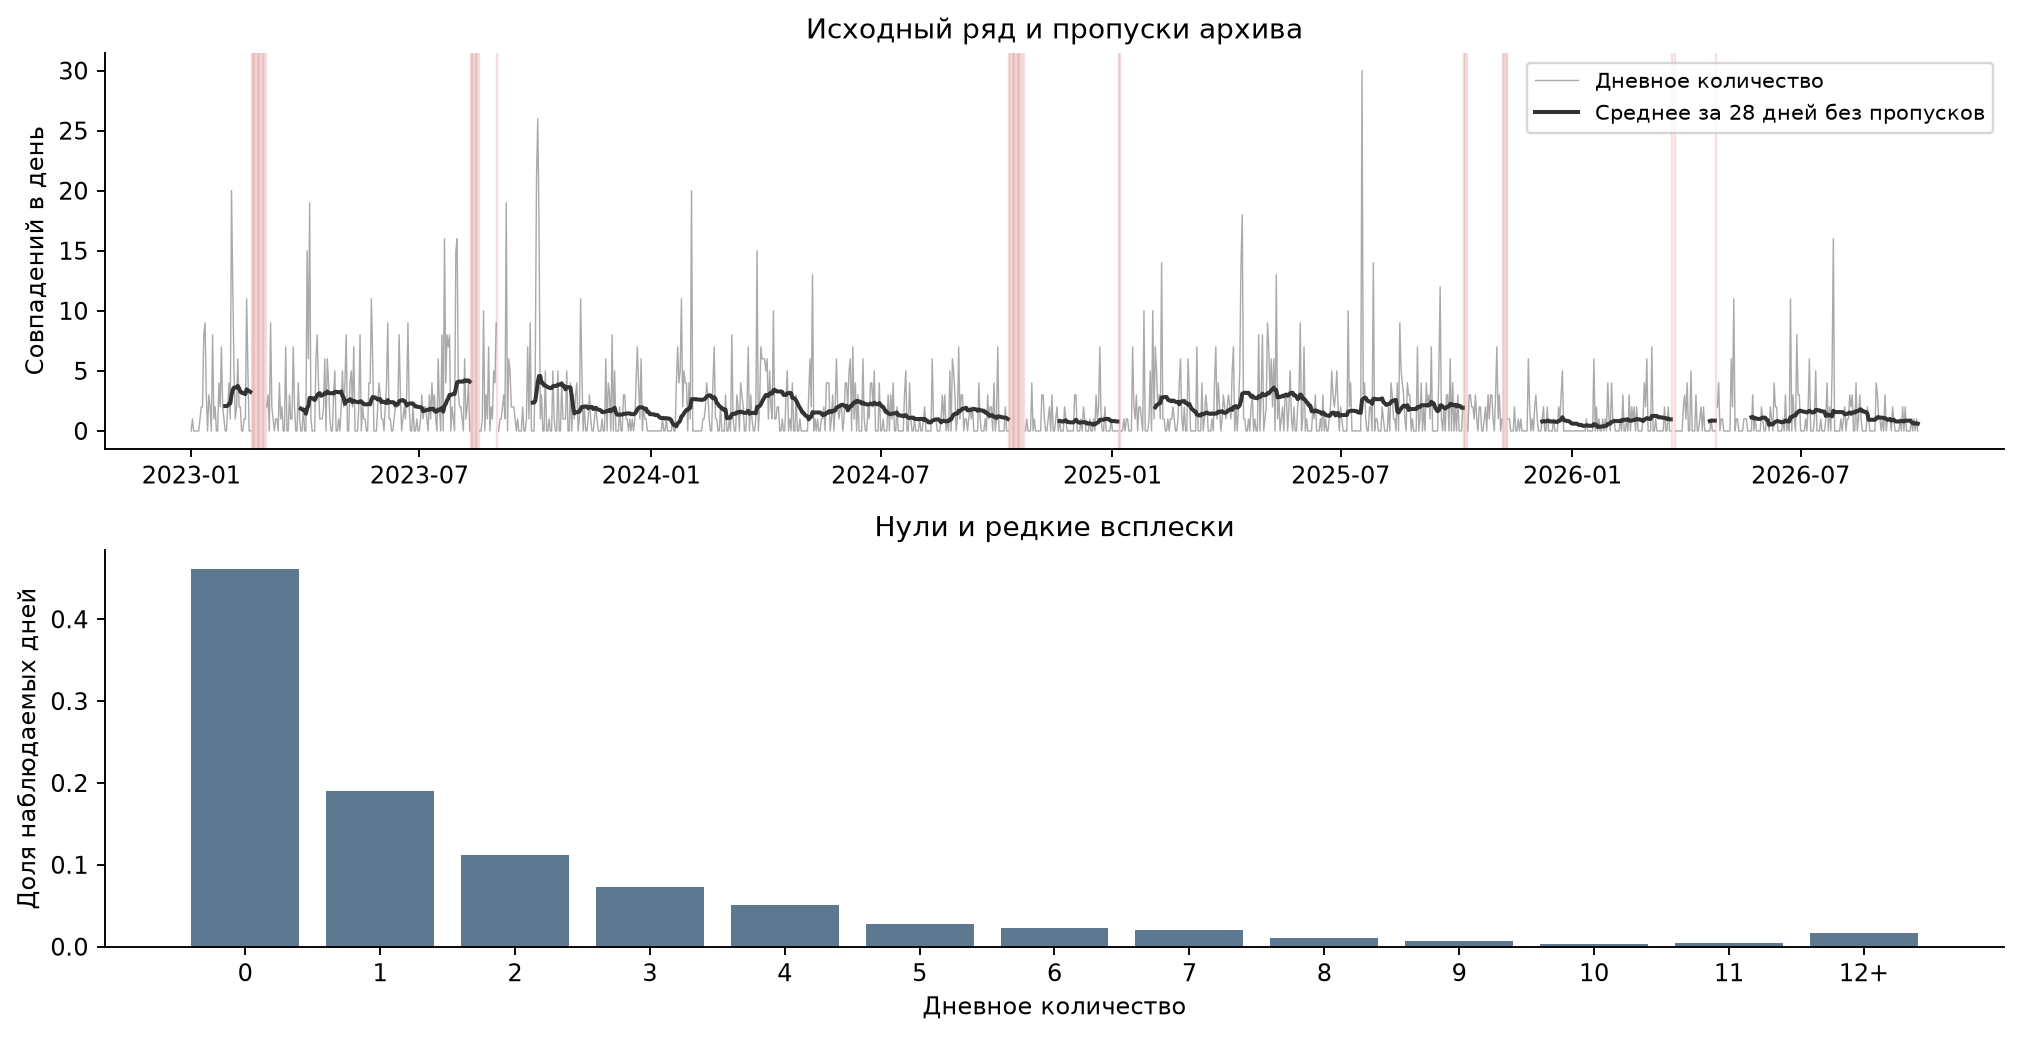

In [3]:
fig,axes=plt.subplots(2,1,figsize=(12,6.2))
axes[0].plot(d.date,d.y,color='#aaaaaa',lw=.6,label='Дневное количество')
axes[0].plot(d.date,d.y.rolling(28,min_periods=28).mean(),color='#333333',lw=1.7,label='Среднее за 28 дней без пропусков')
for date in d.loc[~d.observed,'date']:
    axes[0].axvline(date,color='#c95050',alpha=.18,lw=1)
axes[0].set(title='Исходный ряд и пропуски архива',ylabel='Совпадений в день')
axes[0].legend(fontsize=9)
counts=np.minimum(d.y.dropna().to_numpy(int),12)
freq=np.bincount(counts,minlength=13)/len(counts)
axes[1].bar(range(13),freq,color='#5f7891')
axes[1].set(xticks=range(13),xticklabels=[str(x) for x in range(12)]+['12+'],xlabel='Дневное количество',ylabel='Доля наблюдаемых дней',title='Нули и редкие всплески')
show_plot(fig,'01_data.png')

## 2. Общие вычисления для Bayesian моделей

Для M2/M3 используется Metropolis–Hastings: четыре цепи по 1 200 сохранённых draws после warmup. Нормальная аппроксимация около моды нужна только для построения предложения; принятие считается по точной posterior плотности. Код проверяет rank-normalized split/folded R-hat и ESS по автокорреляциям.


In [4]:
def nb_logpmf(y,mu,k):
    return (gammaln(y+k)-gammaln(k)-gammaln(y+1)+k*(np.log(k)-np.log(k+mu))
            +y*(np.log(mu)-np.log(k+mu)))

def design(dates,calendar=False,center=0):
    dates=pd.DatetimeIndex(dates)
    if not calendar:return np.ones((len(dates),1))
    years=np.asarray((dates-pd.Timestamp('2023-01-01')).days)/365.25-center
    # Orthonormal contrasts give exactly sum-zero population effects.
    month=helmert(12,full=False).T[dates.month-1]
    dow=helmert(7,full=False).T[dates.dayofweek]
    return np.column_stack([np.ones(len(dates)),years,month,dow])

def posterior_problem(d,calendar):
    ok=d.observed.to_numpy()
    dates=d.date[ok]
    center=float(np.mean((dates-pd.Timestamp('2023-01-01')).dt.days)/365.25) if calendar else 0
    X=design(dates,calendar,center)
    y=d.y[ok].to_numpy(float)
    sd=np.array([1.5,.5]+[.4]*17+[1.5]) if calendar else np.array([1.5,1.5])
    prior=np.zeros(len(sd));prior[0]=np.log(2)
    initial=prior.copy();initial[0]=np.log(max(y.mean(),.1));initial[-1]=np.log(.7)
    fact=gammaln(y+1)
    def fun(theta):
        eta=X@theta[:-1]
        if np.max(np.abs(eta))>35 or abs(theta[-1])>15:
            return 1e100,np.zeros_like(theta)
        mu=np.exp(eta);k=np.exp(theta[-1]);den=mu+k
        ll=gammaln(y+k)-gammaln(k)-fact+k*(theta[-1]-np.log(den))+y*(eta-np.log(den))
        g_eta=k*(y-mu)/den
        gk=k*(digamma(y+k)-digamma(k)+theta[-1]-np.log(den)+1-(k+y)/den)
        diff=(theta-prior)/sd
        grad=np.r_[X.T@g_eta,gk.sum()]-(theta-prior)/sd**2
        return float(-ll.sum()+.5*np.dot(diff,diff)),-grad
    return fun,initial,center

def diagnostics(chains):
    # Rank-normalized split Rhat, also folded, following the modern diagnostic.
    m,n,p=chains.shape
    half=n//2
    c=np.concatenate([chains[:,:half],chains[:,-half:]],axis=0)
    def rh(z):
        W=z.var(axis=1,ddof=1).mean(axis=0)
        B=z.shape[1]*z.mean(axis=1).var(axis=0,ddof=1)
        return np.sqrt(((z.shape[1]-1)/z.shape[1]*W+B/z.shape[1])/W)
    z=np.empty_like(c);fold=np.empty_like(c)
    for j in range(p):
        a=c[:,:,j];N=a.size
        z[:,:,j]=norm.ppf((rankdata(a.ravel()).reshape(a.shape)-.375)/(N+.25))
        a=np.abs(a-np.median(a))
        fold[:,:,j]=norm.ppf((rankdata(a.ravel()).reshape(a.shape)-.375)/(N+.25))
    rhat=np.maximum(rh(z),rh(fold))
    # Conservative per-chain autocorrelation ESS, aggregated over chains.
    ess=[]
    for j in range(p):
        total=0
        for a in chains[:,:,j]:
            a=a-a.mean();ft=np.fft.rfft(a,n=2*n)
            ac=np.fft.irfft(ft*np.conj(ft))[:n];ac=ac/ac[0]
            pairs=ac[1:-1:2]+ac[2::2]
            end=np.flatnonzero(pairs<0)
            positive=pairs[:end[0]] if len(end) else pairs
            total+=n/max(1,1+2*np.minimum.accumulate(positive).sum())
        ess.append(total)
    return float(rhat.max()),float(min(ess))

def fit_nb(d,calendar,seed,draws=1200,warm=300):
    fun,x0,center=posterior_problem(d,calendar)
    opt=minimize(fun,x0,jac=True,method='BFGS',options={'gtol':1e-6,'maxiter':350})
    # Build the local Hessian directly; do not trust the BFGS inverse approximation.
    x=opt.x;p=len(x);eps=1e-4
    H=np.column_stack([(fun(x+np.eye(p)[j]*eps)[1]-fun(x-np.eye(p)[j]*eps)[1])/(2*eps) for j in range(p)])
    eigen,U=np.linalg.eigh((H+H.T)/2)
    cov=(U/np.maximum(eigen,1e-4))@U.T
    proposal=multivariate_t(loc=x,shape=cov,df=8)
    rng=np.random.default_rng(seed)
    samples=np.empty((4,draws,p));accepted=[]
    # Batched proposal generation avoids sampling overhead inside MH.
    for chain in range(4):
        candidates=proposal.rvs(size=draws+warm,random_state=rng)
        q=proposal.logpdf(candidates)
        current=x.copy();target=-fun(current)[0]-float(proposal.logpdf(current));acc=0
        logu=np.log(rng.random(draws+warm))
        for i,candidate in enumerate(candidates):
            proposed=-fun(candidate)[0]-q[i]
            if logu[i]<proposed-target:
                current=candidate;target=proposed
                if i>=warm:acc+=1
            if i>=warm:samples[chain,i-warm]=current
        accepted.append(acc/draws)
    rhat,ess=diagnostics(samples)
    diag={'calendar':calendar,'n_train':int(d.observed.sum()),'max_rank_split_rhat':rhat,
          'min_autocorrelation_ess':ess,'acceptance':accepted,
          'gradient_max':float(abs(fun(x)[1]).max()),'optimizer_success':bool(opt.success),
          'draws_per_chain':draws,'warmup':warm,'center_years':center,
          'map':x.tolist()}
    if rhat>1.03 or ess<250:
        if draws<4800:return fit_nb(d,calendar,seed,draws*2,warm*2)
        raise RuntimeError(f'Unreliable posterior sampling: {diag}')
    return {'theta':samples.reshape(-1,p),'center':center,'calendar':calendar,'diagnostics':diag}

def static_predict(fit,dates,n,seed):
    rng=np.random.default_rng(seed)
    theta=fit['theta'][rng.integers(len(fit['theta']),size=n)]
    X=design(dates,fit['calendar'],fit['center'])
    mu=np.exp(theta[:,:-1]@X.T);k=np.exp(theta[:,-1,None])
    draws=rng.negative_binomial(k,k/(k+mu))
    return draws,mu.mean(axis=0),{'mu':mu,'k':k}

## 3. M1: постоянный уровень

$$Y_tmidlambdasimmathrm{Poisson}(lambda),qquad lambdasimmathrm{Gamma}(1,1).$$

После наблюдений Gamma posterior рассчитывается аналитически. В каждой будущей траектории один общий draw интенсивности используется для всех дней. Поэтому модель даёт одинаковое ожидаемое количество по дням и сохраняет зависимость из-за неизвестного общего уровня.


In [5]:
prediction_seed=SEED+5000
rng=np.random.default_rng(prediction_seed)
shape=1+d.y.sum()
rate=1+d.observed.sum()
lambda_draws=rng.gamma(shape,1/rate,N_DRAWS)
mu1=np.repeat(lambda_draws[:,None],len(dates),axis=1)
forecasts={'M1':(rng.poisson(mu1),mu1.mean(0),{'mu':mu1})}
print(f'M1: ожидаемое количество за день ≈ {mu1.mean():.3f}')

M1: ожидаемое количество за день ≈ 1.770


## 4. M2: дополнительная дисперсия

$$Y_tsimmathrm{NB}(mu,kappa),qquad mathrm{Var}(Y_t)=mu+mu^2/kappa.$$

Средний уровень остаётся постоянным, но дневные значения могут колебаться сильнее, чем в Poisson. Priors: $logmusim N(log 2,1.5^2)$, $logkappasim N(0,1.5^2)$. На следующем графике сравниваются прогнозные распределения M1/M2; последний столбец объединяет значения 12 и выше.


,Модель,R-hat максимум,ESS минимум,Медиана kappa
0,M2,1.001,3713.516,0.513


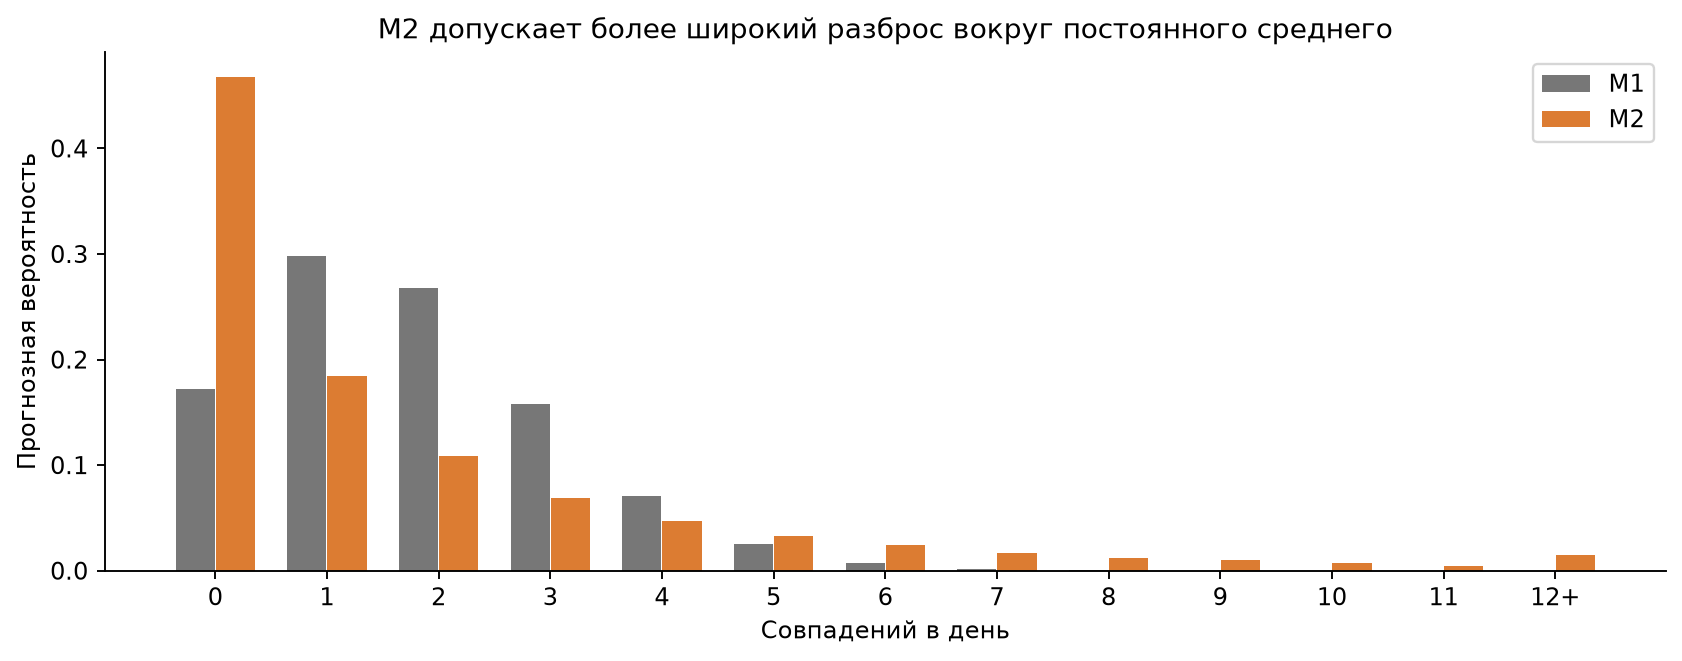

In [6]:
fit2=fit_nb(d,False,prediction_seed+2)
forecasts['M2']=static_predict(fit2,dates,N_DRAWS,prediction_seed+12)
display(pd.DataFrame([{'Модель':'M2','R-hat максимум':fit2['diagnostics']['max_rank_split_rhat'],'ESS минимум':fit2['diagnostics']['min_autocorrelation_ess'],'Медиана kappa':np.median(np.exp(fit2['theta'][:,-1]))}]).round(3))
fig,ax=plt.subplots(figsize=(10,4))
for model,shift in [('M1',-.18),('M2',.18)]:
    draws=forecasts[model][0][:,0]
    probabilities=np.bincount(np.minimum(draws,12),minlength=13)/len(draws)
    ax.bar(np.arange(13)+shift,probabilities,width=.35,color=COLORS[model],label=model)
ax.set(xticks=range(13),xticklabels=[str(x) for x in range(12)]+['12+'],ylabel='Прогнозная вероятность',xlabel='Совпадений в день',title='M2 допускает более широкий разброс вокруг постоянного среднего')
ax.legend()
show_plot(fig,'02_poisson_vs_nb.png')

## 5. M3: календарь, тренд и частичное объединение

$$logmu_t=alpha+eta u_t+b_{	ext{месяц}(t)}+c_{	ext{день недели}(t)}.$$

Эффекты календарных групп имеют общий prior с масштабом 0,4 и нулевую сумму. Priors стягивают шумные группы к общему уровню; масштабы фиксированы. Для тренда $etasim N(0,0.5^2)$, время измерено в годах и центрировано на обучающем периоде.

График показывает **множители среднего количества**, а не вероятности: 1 означает общий уровень, 0,5 — половину общего уровня. Черты показывают 80%-е posterior интервалы календарных эффектов. Это оценённые ассоциации, а не установленное влияние дня недели на эфир.


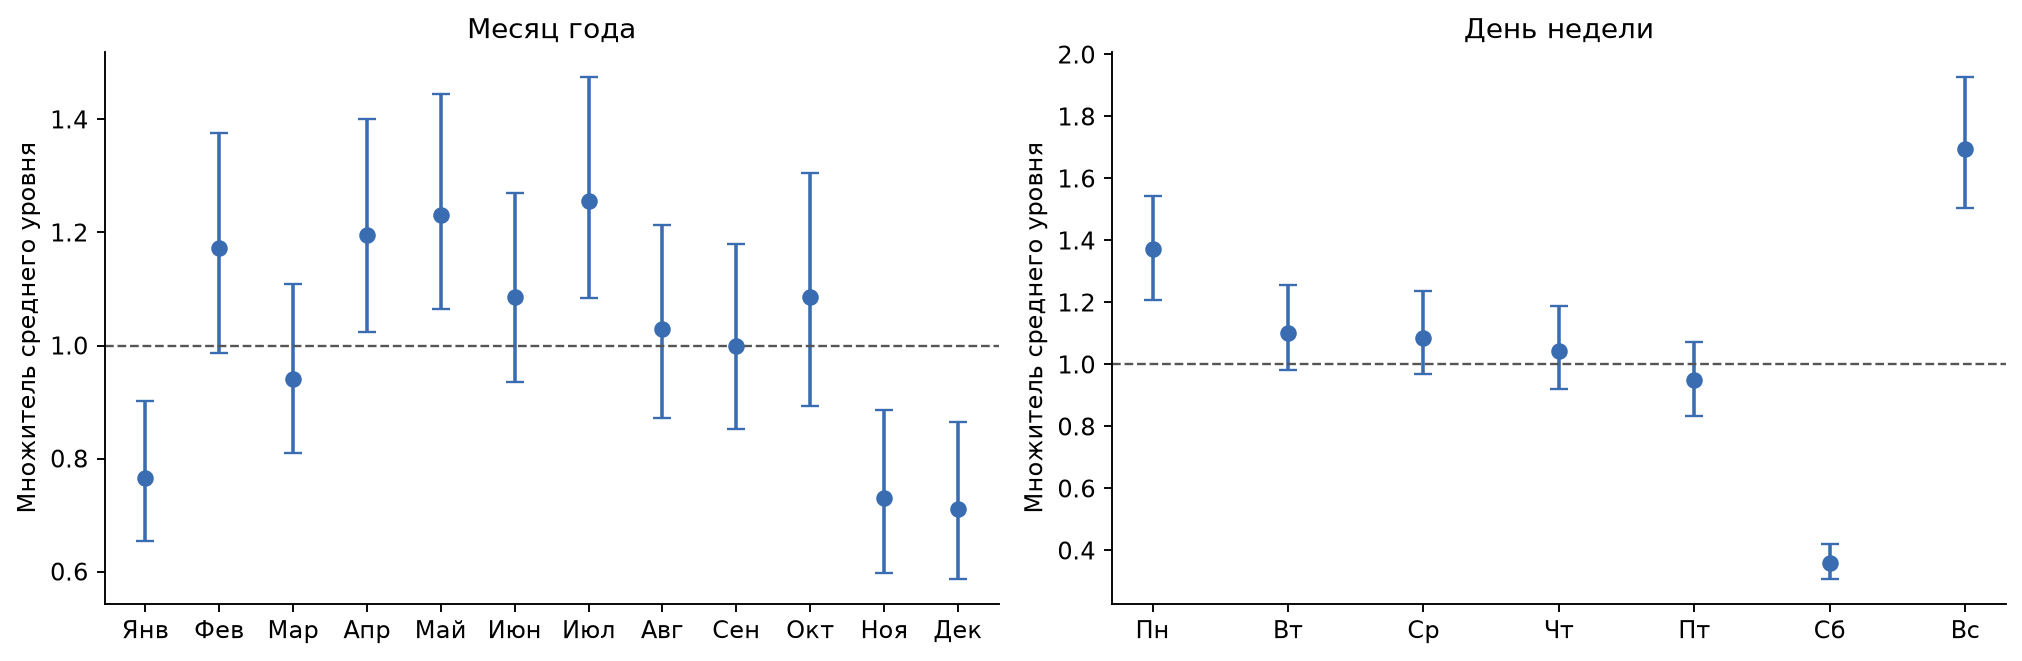

,Модель,R-hat максимум,ESS минимум,Медиана годового log-тренда
0,M3,1.005,1492.863,-0.275


In [7]:
fit3=fit_nb(d,True,prediction_seed+3)
forecasts['M3']=static_predict(fit3,dates,N_DRAWS,prediction_seed+13)
month_multipliers=np.exp(fit3['theta'][:,2:13]@helmert(12,full=False))
weekday_multipliers=np.exp(fit3['theta'][:,13:19]@helmert(7,full=False))
fig,axes=plt.subplots(1,2,figsize=(12,4))
for ax,values,labels,title in [(axes[0],month_multipliers,MONTHS,'Месяц года'),(axes[1],weekday_multipliers,DOW,'День недели')]:
    lo,med,hi=np.quantile(values,[.1,.5,.9],axis=0)
    ax.errorbar(np.arange(len(labels)),med,yerr=[med-lo,hi-med],fmt='o',color=COLORS['M3'],capsize=4)
    ax.axhline(1,color='#555555',ls='--',lw=1)
    ax.set(xticks=range(len(labels)),xticklabels=labels,ylabel='Множитель среднего уровня',title=title)
show_plot(fig,'03_calendar_effects.png')
display(pd.DataFrame([{'Модель':'M3','R-hat максимум':fit3['diagnostics']['max_rank_split_rhat'],'ESS минимум':fit3['diagnostics']['min_autocorrelation_ess'],'Медиана годового log-тренда':np.median(fit3['theta'][:,1])}]).round(3))

## 6. M4: фильтр скрытого уровня

$$logmu_t=alpha+eta u_t+b_{	ext{месяц}(t)}+c_{	ext{день недели}(t)}+ell_t,$$
$$ell_t=ell_{t-1}+arepsilon_t,qquadarepsilon_tsim N(0,q^2).$$

$q=0.03$ выбран в предыдущем расчёте по отдельному development-периоду 2024 года. Для обновления состояния используется NB-вероятность нового наблюдения. При пропуске выполняется только движение состояния. На будущих днях обновления по неизвестным исходам не выполняются.

Вычисление модульное: 128 draws статических параметров M3, по 64 частицы состояния для каждого draw. Веса между статическими draws не переоцениваются. Это приближение к совместному Bayesian анализу; все ограничения описаны в `README.md`.


In [8]:
def filter_state(d,fit,q,particles=8192,seed=1,trace=False):
    """Modular posterior mixture: filter separately conditional on static draws.

    128 static posterior draws, each with an independent state particle filter.
    Observations update states within each draw, not static-draw weights.
    Thus this is deliberately a cut/modular posterior, not exact full Bayes.
    """
    rng=np.random.default_rng(seed)
    groups=128;per=max(32,particles//groups)
    theta=fit['theta'][rng.integers(len(fit['theta']),size=groups)]
    X=design(d.date,True,fit['center']);base=theta[:,:-1]@X.T
    k=np.exp(theta[:,-1,None])
    state=rng.normal(0,.3,(groups,per))
    logweights=np.full((groups,per),-np.log(per))
    miness=[];meaness=[];history=[]
    for i,y in enumerate(d.y):
        state+=rng.normal(0,q,state.shape)
        if np.isfinite(y):
            mu=np.exp(base[:,i,None]+state)
            lw=logweights+nb_logpmf(y,mu,k)
            logweights=lw-logsumexp(lw,axis=1,keepdims=True)
            w=np.exp(logweights)
            if trace:
                # Conditional filtering summary, using current weights, not future states.
                weights=w.ravel()/groups;values=mu.ravel()
                order=np.argsort(values);cdf=np.cumsum(weights[order]);cdf[-1]=1
                lo,med,hi=np.interp([.1,.5,.9],cdf,values[order])
                history.append({'date':str(d.date.iloc[i].date()),'observed':True,
                  'state_mean':float(np.sum(w*state)/groups),
                  'intensity_mean':float(np.sum(w*mu)/groups),
                  'intensity_lo80':float(lo),'intensity_median':float(med),'intensity_hi80':float(hi)})
            ess=1/(w*w).sum(axis=1)
            miness.append(float(ess.min()));meaness.append(float(ess.mean()))
            # Resample only concentrated groups; preserve weights otherwise.
            resample=np.flatnonzero(ess<per/2)
            for g in resample:
                u=(rng.random()+np.arange(per))/per
                cdf=w[g].cumsum();cdf[-1]=1
                state[g]=state[g,np.searchsorted(cdf,u)]
                logweights[g]=-np.log(per)
        elif trace:
            w=np.exp(logweights);mu=np.exp(base[:,i,None]+state)
            weights=w.ravel()/groups;values=mu.ravel();order=np.argsort(values)
            cdf=np.cumsum(weights[order]);cdf[-1]=1
            lo,med,hi=np.interp([.1,.5,.9],cdf,values[order])
            history.append({'date':str(d.date.iloc[i].date()),'observed':False,
              'state_mean':float(np.sum(w*state)/groups),'intensity_mean':float(np.sum(w*mu)/groups),
              'intensity_lo80':float(lo),'intensity_median':float(med),'intensity_hi80':float(hi)})
    # Final resampling produces equally weighted draws from each filtering belief.
    for g in range(groups):
        u=(rng.random()+np.arange(per))/per
        cdf=np.exp(logweights[g]).cumsum();cdf[-1]=1
        state[g]=state[g,np.searchsorted(cdf,u)]
    result={'groups':groups,'particles_per_group':per,'q':q,
                       'min_pre_resampling_ess':min(miness),
                       'mean_pre_resampling_ess':float(np.mean(meaness))}
    if trace:result['history']=history
    return theta,state,result

def dynamic_predict(d,fit,dates,q,n,seed,particles=8192):
    theta,state,diag=filter_state(d,fit,q,particles,seed)
    rng=np.random.default_rng(seed+100000)
    g=rng.integers(len(theta),size=n);j=rng.integers(state.shape[1],size=n)
    level=state[g,j].copy();theta=theta[g]
    X=design(dates,True,fit['center']);base=theta[:,:-1]@X.T
    k=np.exp(theta[:,-1,None]);mu=np.empty((n,len(dates)));draws=np.empty_like(mu,dtype=int)
    for i in range(len(dates)):
        level+=rng.normal(0,q,n)
        mu[:,i]=np.exp(base[:,i]+level)
        draws[:,i]=rng.negative_binomial(k[:,0],k[:,0]/(k[:,0]+mu[:,i]))
    return draws,mu.mean(axis=0),{'mu':mu,'k':k},diag

s4,m4,dist4,particle_diag=dynamic_predict(d,fit3,dates,q,N_DRAWS,prediction_seed+14)
forecasts['M4']=(s4,m4,dist4)
_,final_states,trace_diag=filter_state(d,fit3,q,8192,prediction_seed+14,trace=True)
trace=pd.DataFrame(trace_diag.pop('history'))
trace['date']=pd.to_datetime(trace.date)
trace.to_csv(OUT/'filtered_state_history.csv',index=False,encoding='utf-8-sig')
assert len(trace)==len(d)
print('Частиц:',particle_diag['groups']*particle_diag['particles_per_group'])

Частиц: 8192


### Как наблюдения меняют уровень M4

График ниже — **ретроспективная иллюстрация механизма фильтра**, условная на статических параметрах, оценённых по всему доступному прошлому. Состояния не сглаживаются будущими состояниями, но статические параметры используют весь период. Поэтому этот график не заменяет хронологическую историческую проверку.

Зелёная полоса — 80%-й интервал скрытой ожидаемой интенсивности. Он отличается от прогнозного интервала для фактического дневного количества: наблюдения имеют дополнительный NB-разброс.


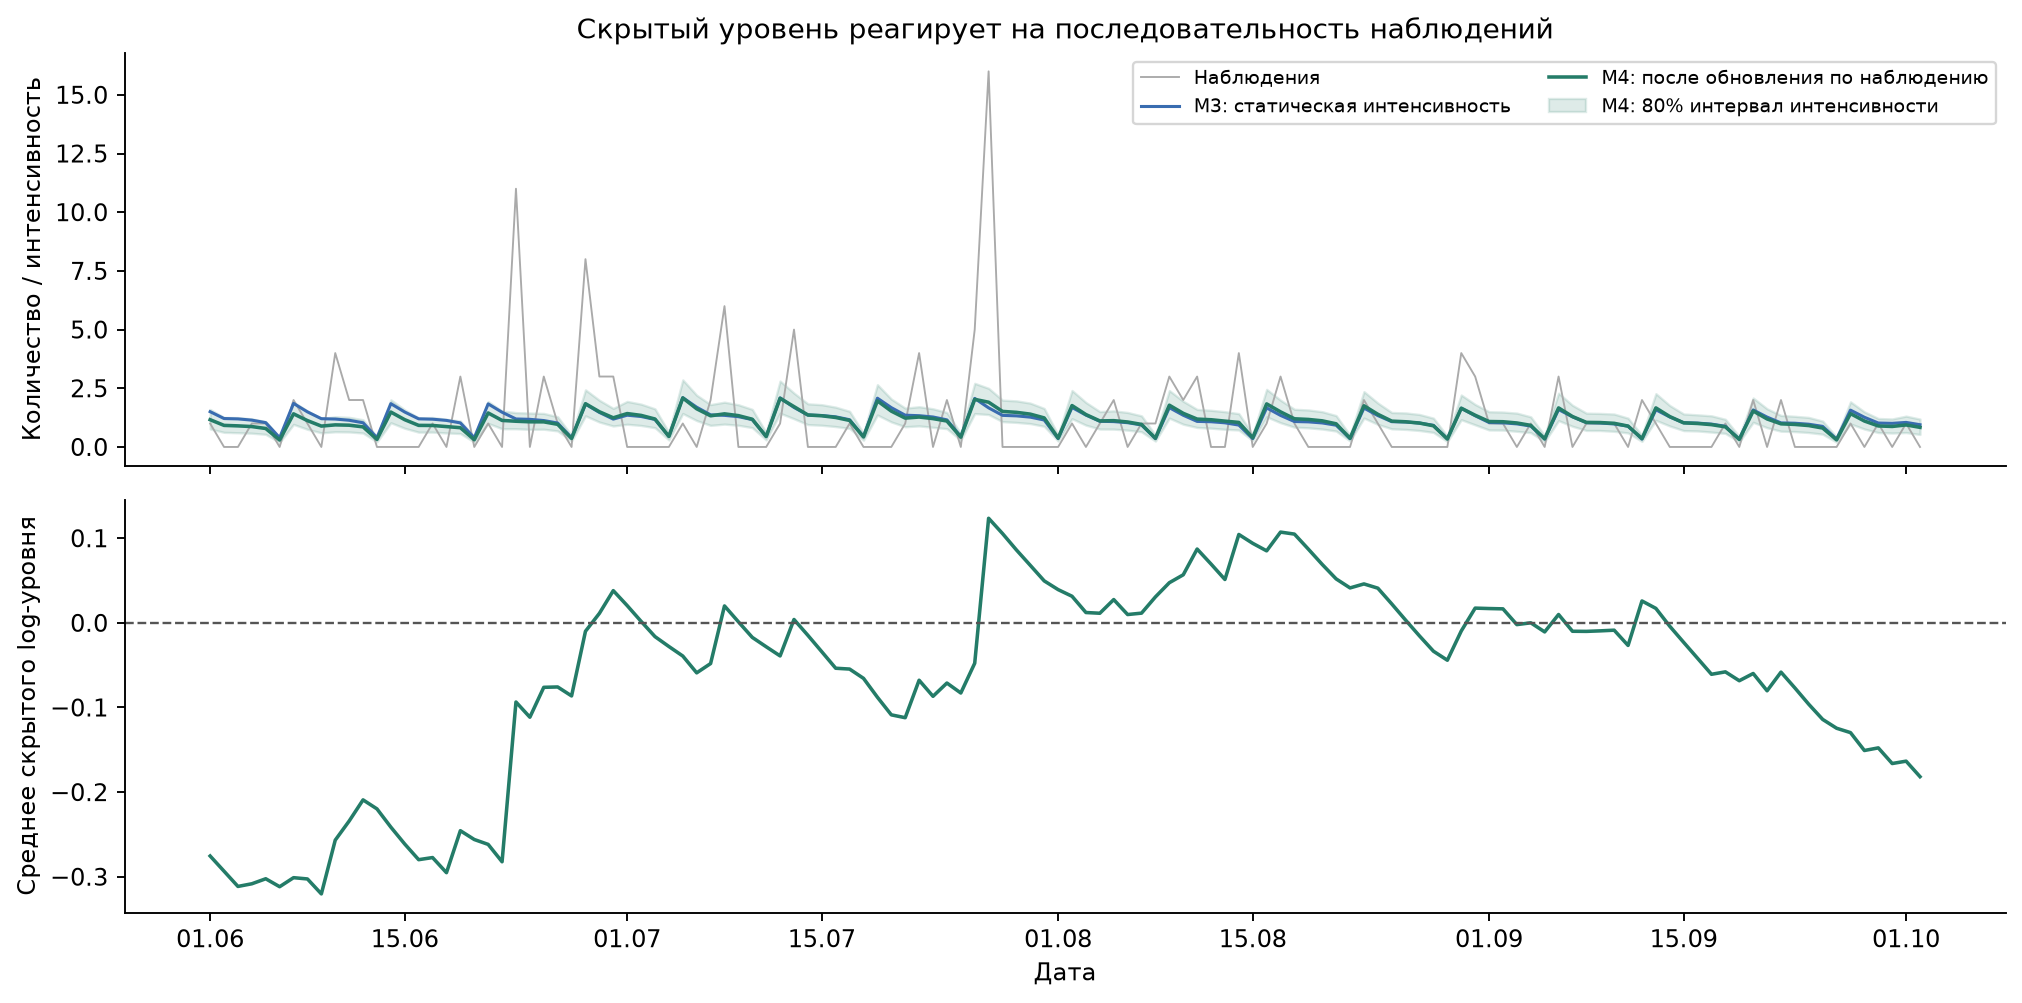

In [9]:
static_history_mu=np.exp(fit3['theta'][:,:-1]@design(d.date,True,fit3['center']).T).mean(0)
recent=(d.date>=pd.Timestamp('2026-06-01')).to_numpy()
view=trace.loc[recent]
fig,axes=plt.subplots(2,1,figsize=(12,6),sharex=True)
axes[0].plot(d.loc[recent,'date'],d.loc[recent,'y'],color='#aaaaaa',lw=.8,label='Наблюдения')
axes[0].plot(d.loc[recent,'date'],static_history_mu[recent],color=COLORS['M3'],lw=1.3,label='M3: статическая интенсивность')
axes[0].plot(view.date,view.intensity_mean,color=COLORS['M4'],lw=1.5,label='M4: после обновления по наблюдению')
axes[0].fill_between(view.date,view.intensity_lo80,view.intensity_hi80,color=COLORS['M4'],alpha=.15,label='M4: 80% интервал интенсивности')
axes[0].set(ylabel='Количество / интенсивность',title='Скрытый уровень реагирует на последовательность наблюдений')
axes[0].legend(fontsize=8,ncol=2)
axes[1].plot(view.date,view.state_mean,color=COLORS['M4'])
axes[1].axhline(0,color='#555555',ls='--',lw=1)
axes[1].set(ylabel='Среднее скрытого log-уровня',xlabel='Дата')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
show_plot(fig,'04_dynamic_filter.png')

## 7. Прогноз каждого дня

Главный точечный прогноз — **среднее**, подходящее для квадратичной функции потерь. Оно может быть дробным: 0,32 означает ожидаемое количество по распределению, а не треть произнесённого слова. Медиана M4 дополнительно приведена как целое число; при большой вероятности нуля она равна нулю даже при положительном среднем.

Для дискретных количеств границы интервалов вычислены через обратную эмпирическую CDF (`method="inverted_cdf"`), поэтому они целые. Вероятность хотя бы одного упоминания рассчитана по прогнозным траекториям. Интервалы относятся к измеряемому ASR-ряду и не учитывают ошибки распознавания или неизвестную неполноту эфира.


In [10]:
daily_rows=[]
monthly_rows=[]
for model,(draws,mean,distribution) in forecasts.items():
    quant=np.quantile(draws,[.025,.1,.5,.9,.975],axis=0,method='inverted_cdf')
    for i,date in enumerate(dates):
        daily_rows.append({'model':model,'date':date.strftime('%Y-%m-%d'),'weekday':DOW[date.dayofweek],
          'mean':float(mean[i]),'median':int(quant[2,i]),'lo80':int(quant[1,i]),'hi80':int(quant[3,i]),
          'lo95':int(quant[0,i]),'hi95':int(quant[4,i]),'probability_at_least_one':float((draws[:,i]>=1).mean())})
    sums=draws.sum(1)
    qs=np.quantile(sums,[.025,.1,.5,.9,.975],method='inverted_cdf')
    monthly_rows.append({'model':model,'mean':float(mean.sum()),'median':int(qs[2]),'lo80':int(qs[1]),'hi80':int(qs[3]),'lo95':int(qs[0]),'hi95':int(qs[4])})
daily=pd.DataFrame(daily_rows)
monthly=pd.DataFrame(monthly_rows)
daily.to_csv(OUT/'forecast_daily_discrete.csv',index=False,encoding='utf-8-sig')
wide=daily.pivot(index='date',columns='model',values='mean').rename(columns=lambda x:x+'_mean')
best=daily[daily.model=='M4'].set_index('date')
wide.insert(0,'weekday',best.weekday)
for col in ['median','lo80','hi80','lo95','hi95','probability_at_least_one']:
    wide['M4_'+col]=best[col]
wide.to_csv(OUT/'forecast_daily_all_models.csv',encoding='utf-8-sig')
pretty=wide.copy()
pretty.index=pd.to_datetime(pretty.index).strftime('%d.%m.%Y')
pretty=pretty.rename(columns={'weekday':'День недели','M1_mean':'M1 среднее','M2_mean':'M2 среднее','M3_mean':'M3 среднее','M4_mean':'M4 среднее','M4_median':'M4 медиана'})
pretty['M4 80% интервал']=best.lo80.astype(str).to_numpy()+'–'+best.hi80.astype(str).to_numpy()
pretty['M4 95% интервал']=best.lo95.astype(str).to_numpy()+'–'+best.hi95.astype(str).to_numpy()
pretty['M4 P(≥1)']=best.probability_at_least_one.map(lambda x:f'{100*x:.1f}%').to_numpy()
pretty=pretty[['День недели','M1 среднее','M2 среднее','M3 среднее','M4 среднее','M4 медиана','M4 80% интервал','M4 95% интервал','M4 P(≥1)']]
with pd.option_context('display.max_rows',40,'display.max_columns',12):
    display(pretty.round(2))

model,День недели,M1 среднее,M2 среднее,M3 среднее,M4 среднее,M4 медиана,M4 80% интервал,M4 95% интервал,M4 P(≥1)
date,,,,,,,,,
03.10.2026,Сб,1.77,1.77,0.36,0.32,0,0–1,0–2,22.1%
04.10.2026,Вс,1.77,1.77,1.70,1.49,1,0–4,0–8,52.3%
05.10.2026,Пн,1.77,1.77,1.37,1.18,0,0–3,0–7,48.1%
06.10.2026,Вт,1.77,1.77,1.10,0.96,0,0–3,0–6,43.1%
07.10.2026,Ср,1.77,1.77,1.09,0.95,0,0–3,0–5,43.5%
08.10.2026,Чт,1.77,1.77,1.04,0.92,0,0–3,0–5,42.4%
09.10.2026,Пт,1.77,1.77,0.95,0.83,0,0–3,0–5,40.1%
10.10.2026,Сб,1.77,1.77,0.36,0.32,0,0–1,0–2,22.1%
11.10.2026,Вс,1.77,1.77,1.69,1.48,1,0–4,0–8,52.4%


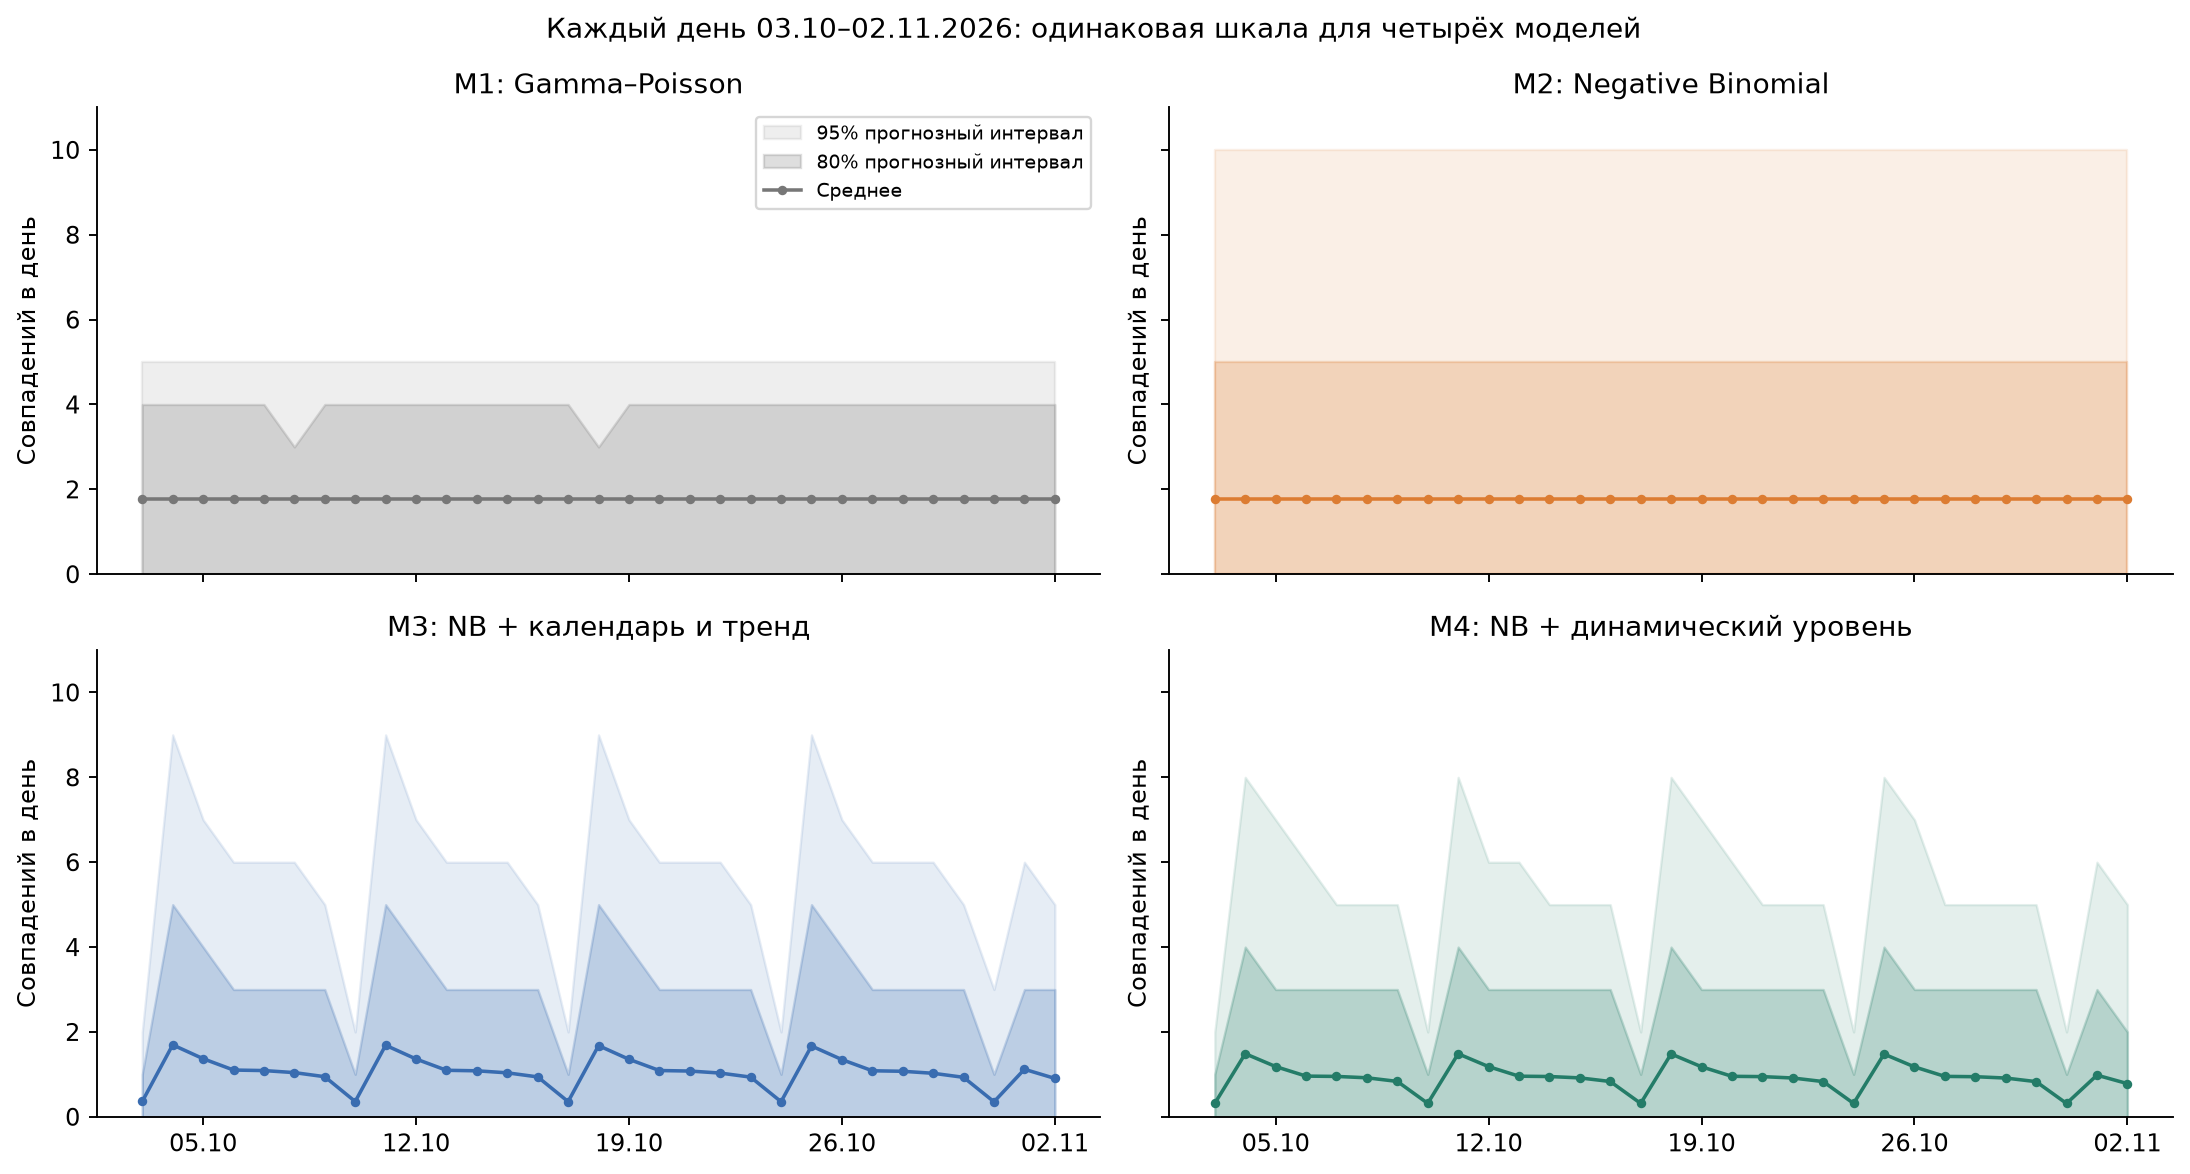

In [11]:
fig,axes=plt.subplots(2,2,figsize=(13,7),sharex=True,sharey=True)
for ax,model in zip(axes.flat,NAMES):
    a=daily[daily.model==model].copy();a['date']=pd.to_datetime(a.date)
    ax.fill_between(a.date,a.lo95,a.hi95,color=COLORS[model],alpha=.12,label='95% прогнозный интервал')
    ax.fill_between(a.date,a.lo80,a.hi80,color=COLORS[model],alpha=.24,label='80% прогнозный интервал')
    ax.plot(a.date,a['mean'],'o-',color=COLORS[model],lw=1.5,ms=3,label='Среднее')
    ax.set(title=f'{model}: {NAMES[model]}',ylabel='Совпадений в день',ylim=(0,daily.hi95.max()+1))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
axes[0,0].legend(fontsize=8)
fig.suptitle('Каждый день 03.10–02.11.2026: одинаковая шкала для четырёх моделей')
show_plot(fig,'05_daily_four_models.png')

### Ожидаемое количество: сравнение моделей

Постоянные M1/M2 имеют одинаковый уровень для всех будущих дней. M3/M4 учитывают день недели и месяц года. Перепад на 1 ноября отражает календарный коэффициент месяца, а не известное будущее событие. Календарный рисунок — модельная оценка; конкретные будущие выпуски программ неизвестны.


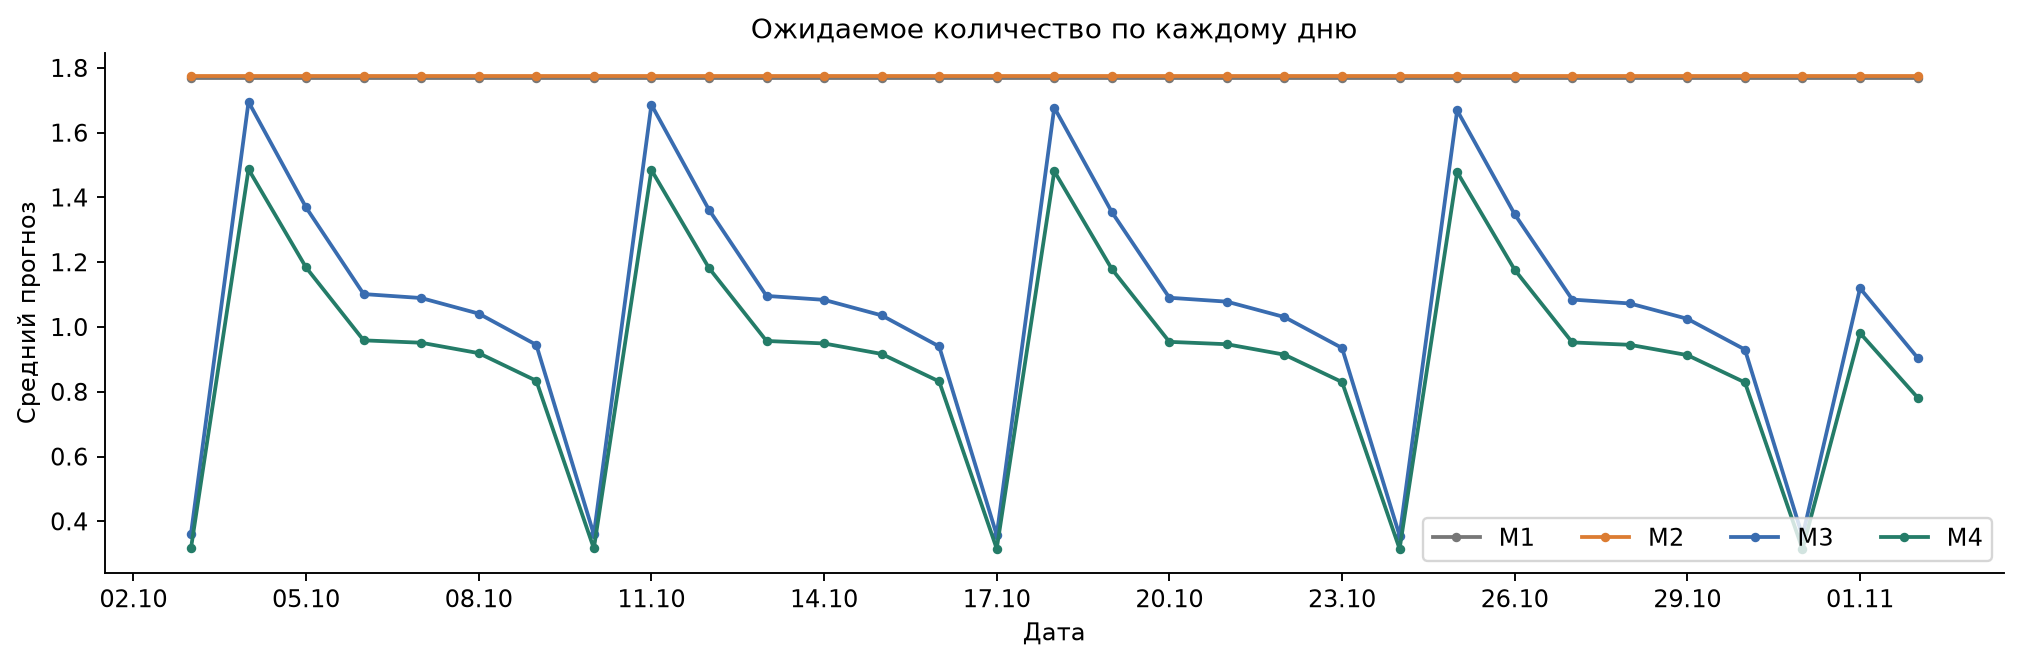

In [12]:
fig,ax=plt.subplots(figsize=(12,4))
for model in NAMES:
    a=daily[daily.model==model]
    ax.plot(pd.to_datetime(a.date),a['mean'],'o-',color=COLORS[model],label=model,ms=3,lw=1.6)
ax.set(title='Ожидаемое количество по каждому дню',ylabel='Средний прогноз',xlabel='Дата')
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
ax.legend(ncol=4)
show_plot(fig,'06_daily_comparison.png')

### Вероятности разных дневных количеств

Для иллюстрации выбраны понедельник 5 октября и суббота 10 октября. Это примеры формы прогнозных распределений, а не отдельные проверки точности: будущие исходы неизвестны. Последний столбец содержит всю вероятность количества 12 и выше.


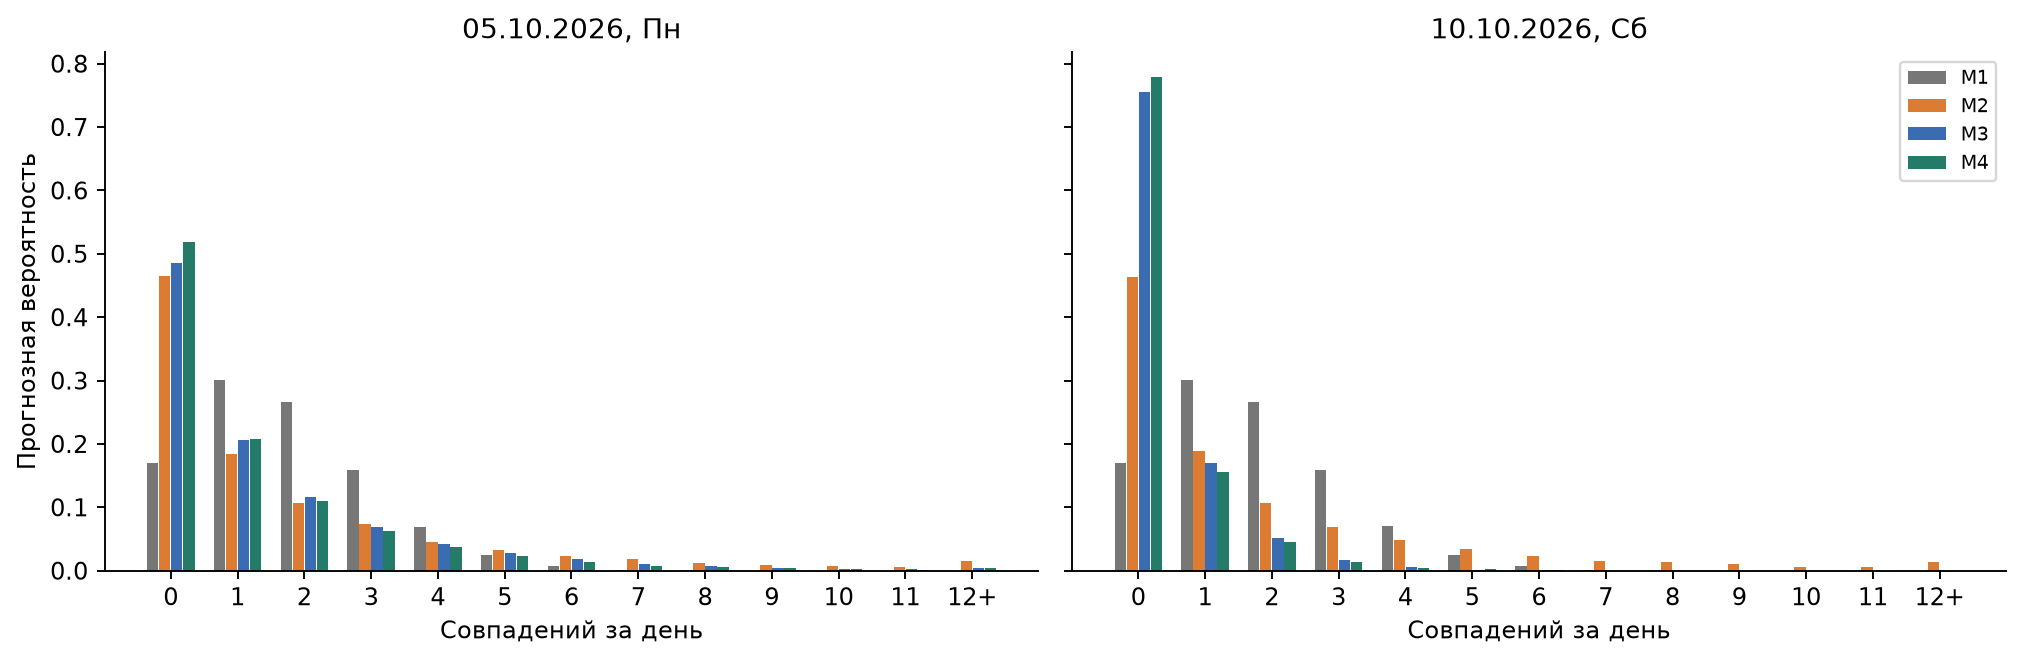

In [13]:
fig,axes=plt.subplots(1,2,figsize=(12,4),sharey=True)
for ax,date in zip(axes,pd.to_datetime(['2026-10-05','2026-10-10'])):
    i=dates.get_loc(date)
    for model,shift in zip(NAMES,[-.27,-.09,.09,.27]):
        samples=forecasts[model][0][:,i]
        prob=np.bincount(np.minimum(samples,12),minlength=13)/len(samples)
        ax.bar(np.arange(13)+shift,prob,width=.17,color=COLORS[model],label=model)
    ax.set(xticks=range(13),xticklabels=[str(x) for x in range(12)]+['12+'],xlabel='Совпадений за день',title=f'{date:%d.%m.%Y}, {DOW[date.dayofweek]}')
axes[0].set_ylabel('Прогнозная вероятность')
axes[1].legend(fontsize=8)
show_plot(fig,'07_daily_distributions.png')

## 8. Сумма за месяц

Дневные средние суммируются. Интервалы месячного итога рассчитываются отдельно из сумм совместных траекторий: складывать верхние и нижние границы дневных интервалов нельзя. M4 даёт около 29 совпадений за весь период, хотя для многих отдельных дней медиана равна нулю.


,model,mean,median,lo80,hi80,lo95,hi95
0,M1,54.88,55,45,64,41,70
1,M2,55.01,53,36,76,28,90
2,M3,32.56,31,19,47,15,58
3,M4,28.60,26,15,45,10,59


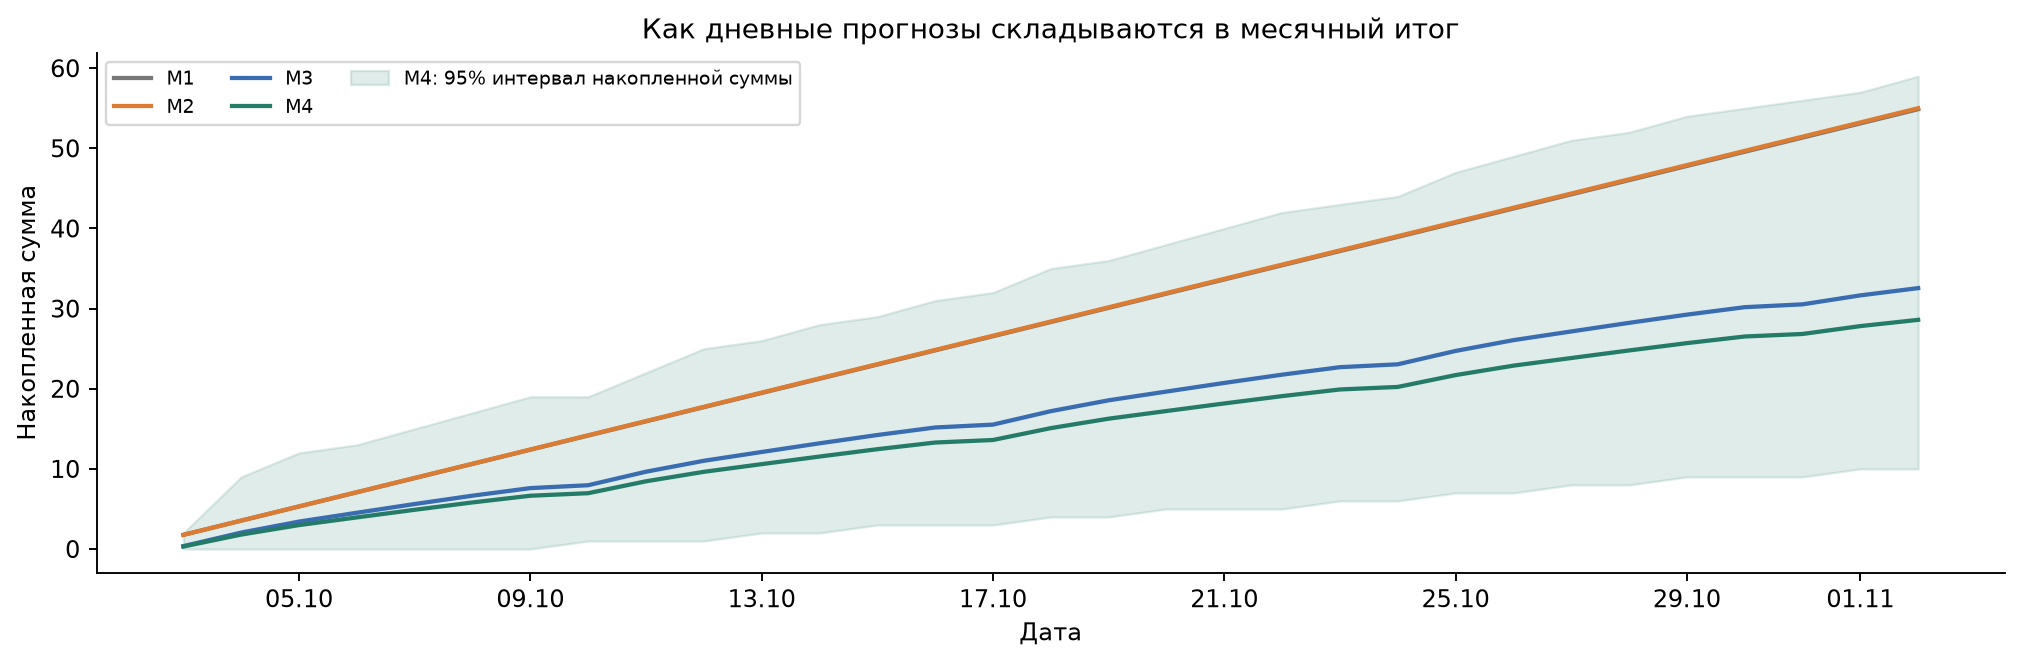

In [14]:
display(monthly.round({'mean':2}))
fig,ax=plt.subplots(figsize=(12,4))
for model,(draws,mean,_) in forecasts.items():
    cumulative=draws.cumsum(axis=1)
    ax.plot(dates,np.cumsum(mean),color=COLORS[model],label=model,lw=1.8)
    if model=='M4':
        lo,hi=np.quantile(cumulative,[.025,.975],axis=0,method='inverted_cdf')
        ax.fill_between(dates,lo,hi,color=COLORS[model],alpha=.14,label='M4: 95% интервал накопленной суммы')
ax.set(title='Как дневные прогнозы складываются в месячный итог',ylabel='Накопленная сумма',xlabel='Дата')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
ax.legend(ncol=3,fontsize=8)
show_plot(fig,'08_cumulative_forecast.png')

## 9. Историческая оценка моделей

Backtest включает 21 прогноз всего следующего месяца, январь 2025 — сентябрь 2026. Каждый прогноз обучается только на предыдущих пригодных днях. Дневная оценка охватывает 626 наблюдений; месячная — 16 месяцев без пропусков. На этом наборе месячный CRPS улучшается при каждом расширении. Дневной MAE и месячный RMSE не обязаны улучшаться на каждом шаге.

Это ретроспективная проверка по текущему снимку архива. Исторические версии расшифровок и время их фактической публикации не восстановлены. M4 выбрана по месячному CRPS; статистическое преимущество над M3 пограничное. Таблица и графики ниже используют сохранённые результаты расчёта с тем же SHA-256 источника. В следующей ячейке содержится весь код исторической проверки для повторного запуска.


In [15]:
def crps_sample(draws,y):
    draws=np.sort(np.asarray(draws),axis=0)
    n=len(draws);weights=(2*np.arange(1,n+1)-n-1)/n**2
    return np.abs(draws-y).mean(axis=0)-np.sum(weights[:,None]*draws,axis=0)

def score(draws,mean,y,distribution=None,seed=1):
    y=np.asarray(y,float);ok=np.isfinite(y)
    yy=y[ok].astype(int);s=draws[:,ok];m=mean[ok]
    result={'n_days':len(yy),'daily_mae':float(np.abs(m-yy).mean()),
            'daily_mse':float(((m-yy)**2).mean()),
            'daily_crps':float(crps_sample(s,yy).mean())}
    for level in [.8,.95]:
        a=(1-level)/2;lo,hi=np.quantile(s,[a,1-a],axis=0)
        result[f'daily_coverage_{int(100*level)}']=float(((yy>=lo)&(yy<=hi)).mean())
        result[f'daily_width_{int(100*level)}']=float((hi-lo).mean())
    rng=np.random.default_rng(seed)
    if distribution is not None:
        mu=distribution['mu'][:,ok];k=distribution.get('k')
        if k is not None:lp=nb_logpmf(yy[None,:],mu,k)
        else:lp=yy[None,:]*np.log(mu)-mu-gammaln(yy[None,:]+1)
        result['daily_nll']=float(-(logsumexp(lp,axis=0)-np.log(len(lp))).mean())
    lower=(s<yy).mean(axis=0);mass=(s==yy).mean(axis=0)
    pit=lower+rng.random(len(yy))*mass
    total=s.sum(axis=1);actual=int(yy.sum());point=float(m.sum())
    lo80,hi80=np.quantile(total,[.1,.9]);lo95,hi95=np.quantile(total,[.025,.975])
    result.update({'actual_sum_observed':actual,'predicted_sum_observed':point,
      'monthly_error':point-actual,'monthly_ae':abs(point-actual),'monthly_se':(point-actual)**2,
      'monthly_crps':float(crps_sample(total[:,None],np.array([actual]))[0]),
      'monthly_lo80':float(lo80),'monthly_hi80':float(hi80),'monthly_lo95':float(lo95),'monthly_hi95':float(hi95),
      'monthly_coverage80':bool(lo80<=actual<=hi80),'monthly_coverage95':bool(lo95<=actual<=hi95),
      'monthly_width80':float(hi80-lo80),'monthly_width95':float(hi95-lo95)})
    return result,pit

def forecast_set(train,dates,n,seed,q=.07,save=False):
    rng=np.random.default_rng(seed)
    a=1+train.y.sum();b=1+train.observed.sum()
    lam=rng.gamma(a,1/b,n);mu=np.repeat(lam[:,None],len(dates),axis=1)
    forecasts={'M1':(rng.poisson(mu),mu.mean(axis=0),{'mu':mu})}
    fit2=fit_nb(train,False,seed+2);fit3=fit_nb(train,True,seed+3)
    forecasts['M2']=static_predict(fit2,dates,n,seed+12)
    forecasts['M3']=static_predict(fit3,dates,n,seed+13)
    a,b,c,diag=dynamic_predict(train,fit3,dates,q,n,seed+14)
    forecasts['M4']=(a,b,c)
    diagnostics_out={'M2':fit2['diagnostics'],'M3':fit3['diagnostics'],'M4':diag}
    if save:
        np.savez_compressed(OUT/'posterior_samples.npz',M2=fit2['theta'],M3=fit3['theta'])
        (OUT/'final_diagnostics.json').write_text(json.dumps(diagnostics_out,ensure_ascii=False,indent=2),encoding='utf-8')
    return forecasts,diagnostics_out,fit3

def summarize(records):
    frame=pd.DataFrame(records)
    rows=[]
    for model,g in frame.groupby('model',sort=False):
        complete=g[g.n_days==g.horizon]
        weights=g.n_days.to_numpy()
        row={'model':model,'name':NAMES[model],'origins':len(g),'observed_test_days':int(g.n_days.sum()),
             'full_months':len(complete)}
        for col in ['daily_mae','daily_mse','daily_crps','daily_nll','daily_coverage_80','daily_coverage_95','daily_width_80','daily_width_95']:
            row[col]=float(np.average(g[col],weights=weights))
        row['daily_rmse']=np.sqrt(row.pop('daily_mse'))
        for col in ['monthly_ae','monthly_crps','monthly_coverage80','monthly_coverage95','monthly_width80','monthly_width95']:
            row[col]=float(complete[col].mean())
        row['monthly_rmse']=float(np.sqrt(complete.monthly_se.mean()))
        rows.append(row)
    return pd.DataFrame(rows)

def paired_comparisons(records):
    # Non-overlapping monthly windows; paired loss differences, lag-1 HAC variance.
    frame=pd.DataFrame(records);frame=frame[frame.n_days==frame.horizon]
    out=[]
    for a,b in [('M1','M2'),('M2','M3'),('M3','M4'),('M1','M4')]:
        A=frame[frame.model==a].set_index('origin');B=frame[frame.model==b].set_index('origin')
        for loss in ['monthly_se','monthly_crps']:
            diff=(A[loss]-B[loss]).to_numpy();N=len(diff);center=diff-diff.mean()
            gamma0=np.dot(center,center)/N;gamma1=np.dot(center[1:],center[:-1])/N
            variance=max(0,gamma0+gamma1)  # Bartlett weight for lag 1 is .5
            se=np.sqrt(variance/N)
            stat=diff.mean()/se if se else 0
            p=2*student_t.sf(abs(stat),df=N-1)
            rng=np.random.default_rng(SEED+N)
            # Circular moving-block bootstrap, two months per block.
            starts=rng.integers(0,N,size=(10000,(N+1)//2))
            inds=np.stack([starts,(starts+1)%N],axis=-1).reshape(10000,-1)[:,:N]
            means=diff[inds].mean(axis=1);lo,hi=np.quantile(means,[.025,.975])
            out.append({'earlier':a,'later':b,'loss':loss,'n_full_months':N,
              'mean_loss_improvement':float(diff.mean()),'DM_HAC_lag1':float(stat),
              'approx_p_two_sided':float(p),'block_bootstrap_lo95':float(lo),'block_bootstrap_hi95':float(hi)})
    return pd.DataFrame(out)

def plots(d,summary,records,future,monthly,pits):
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as plt
    plt.rcParams.update({'font.family':'DejaVu Sans','axes.spines.top':False,
      'axes.spines.right':False,'figure.dpi':140,'savefig.dpi':180})
    colors={'M1':'#969696','M2':'#dc7c32','M3':'#396cb0','M4':'#247c68'}
    figs=OUT/'figures';figs.mkdir(exist_ok=True)
    f=pd.DataFrame(future);f['date']=pd.to_datetime(f.date)
    fig,ax=plt.subplots(figsize=(11,4.6))
    hist=d[d.date>='2026-07-01'];ax.plot(hist.date,hist.y,color='#444444',lw=1,label='Наблюдения')
    for model in NAMES:
        a=f[f.model==model];ax.plot(a.date,a['mean'],label=model,color=colors[model],lw=1.8)
    a=f[f.model=='M4'];ax.fill_between(a.date,a.lo95,a.hi95,color=colors['M4'],alpha=.14,label='M4: 95% прогнозный интервал')
    ax.axvline(pd.Timestamp('2026-10-02'),color='#777',ls='--',lw=1)
    ax.set(ylabel='Совпадения фамилии в день',title='Россия 1: прогноз на 03.10–02.11.2026')
    ax.legend(ncol=3,fontsize=8);fig.autofmt_xdate();fig.tight_layout();fig.savefig(figs/'daily_forecast.png');plt.close(fig)
    fig,axes=plt.subplots(1,2,figsize=(10,4))
    for ax,col,title in zip(axes,['monthly_rmse','monthly_crps'],['Ошибка месячного итога (RMSE)','Вероятностная ошибка (CRPS)']):
        ax.bar(summary.model,summary[col],color=[colors[x] for x in summary.model]);ax.set_title(title);ax.set_ylabel('Меньше лучше')
        for i,v in enumerate(summary[col]):ax.text(i,v,f'{v:.1f}',ha='center',va='bottom')
    fig.suptitle(f'Историческая проверка: {int(summary.full_months.iloc[0])} полностью наблюдаемых месяцев')
    fig.tight_layout();fig.savefig(figs/'evaluation.png');plt.close(fig)
    fig,axes=plt.subplots(1,4,figsize=(12,3),sharey=True)
    for ax,model in zip(axes,NAMES):
        ax.hist(pits[model],bins=np.linspace(0,1,11),density=True,color=colors[model],alpha=.8)
        ax.axhline(1,color='#333',ls='--',lw=1);ax.set_title(model);ax.set_xlabel('Randomized PIT')
    axes[0].set_ylabel('Плотность');fig.suptitle('Калибровка дневных распределений: ориентир — равномерность')
    fig.tight_layout();fig.savefig(figs/'pit.png');plt.close(fig)
    fig,ax=plt.subplots(figsize=(10,4.3))
    r=pd.DataFrame(records);full=r[r.n_days==r.horizon]
    actual=full[full.model=='M1'];ax.plot(pd.to_datetime(actual.test_start),actual.actual_sum_observed,'k.-',label='Факт',lw=2)
    for model in NAMES:
        a=full[full.model==model];ax.plot(pd.to_datetime(a.test_start),a.predicted_sum_observed,'o-',color=colors[model],label=model,ms=3)
    ax.set(ylabel='Совпадения за месяц',title='Месячные итоги: прогнозы сделаны до начала каждого месяца')
    ax.legend(ncol=5);fig.autofmt_xdate();fig.tight_layout();fig.savefig(figs/'backtest_months.png');plt.close(fig)

def main():
    started=time.time();d,source_hash=load_data()
    # Development uses 2024 only. Test: Jan 2025-Sep 2026, 21 monthly occasions.
    # No test month is used to tune q or the calendar priors.
    qs=[0.,.03,.07,.15]
    dev=[];devdiag=[]
    for fold,start in enumerate(pd.date_range('2024-06-01','2024-12-01',freq='MS')):
        end=start+pd.DateOffset(months=1)-pd.Timedelta(days=1)
        train=d[d.date<start];test=d[(d.date>=start)&(d.date<=end)]
        fit=fit_nb(train,True,SEED+100+fold)
        for q in qs:
            s,m,dist,diag=dynamic_predict(train,fit,test.date,q,3000,SEED+200+fold)
            result,_=score(s,m,test.y,dist,SEED+fold)
            dev.append({'origin':(start-pd.Timedelta(days=1)).date().isoformat(),'q':q,
                        'horizon':len(test),**result})
        print('development',start.date(), 'elapsed',round(time.time()-started),flush=True)
    devframe=pd.DataFrame(dev);devframe.to_csv(OUT/'development_scores.csv',index=False)
    complete=devframe[devframe.n_days==devframe.horizon]
    q=float(complete.groupby('q').monthly_crps.mean().idxmin())
    print('frozen q',q,flush=True)
    records=[];pits={m:[] for m in NAMES};diags=[];daily_records=[]
    for fold,start in enumerate(pd.date_range('2025-01-01','2026-09-01',freq='MS')):
        end=start+pd.DateOffset(months=1)-pd.Timedelta(days=1)
        train=d[d.date<start];test=d[(d.date>=start)&(d.date<=end)]
        forecasts,diagnostic,_=forecast_set(train,test.date,6000,SEED+1000+fold*20,q)
        diags.append({'origin':(start-pd.Timedelta(days=1)).date().isoformat(),**diagnostic})
        for model,(s,m,dist) in forecasts.items():
            result,pit=score(s,m,test.y,dist,SEED+3000+fold)
            records.append({'origin':(start-pd.Timedelta(days=1)).date().isoformat(),
                            'test_start':start.date().isoformat(),'test_end':end.date().isoformat(),
                            'model':model,'horizon':len(test),'train_days':int(train.observed.sum()),**result})
            pits[model].extend(pit.tolist())
            lo,hi=np.quantile(s,[.025,.975],axis=0)
            for date,y,point,low,high in zip(test.date,test.y,m,lo,hi):
                daily_records.append({'model':model,'date':date.date().isoformat(),
                                      'actual':y,'mean':point,'lo95':low,'hi95':high})
        pd.DataFrame(records).to_csv(OUT/'backtest_by_origin.csv',index=False)
        print('test',start.date(),'elapsed',round(time.time()-started),flush=True)
    summary=summarize(records);summary.to_csv(OUT/'evaluation.csv',index=False,encoding='utf-8-sig')
    paired_comparisons(records).to_csv(OUT/'model_comparisons.csv',index=False)
    pd.DataFrame(daily_records).to_csv(OUT/'backtest_daily.csv',index=False)
    (OUT/'backtest_diagnostics.json').write_text(json.dumps(diags,indent=2),encoding='utf-8')
    start=d.date.max()+pd.Timedelta(days=1)
    end=d.date.max()+pd.DateOffset(months=1)
    dates=pd.date_range(start,end)
    forecasts,_,fit=forecast_set(d,dates,30000,SEED+5000,q,True)
    future=[];monthly=[]
    for model,(s,m,dist) in forecasts.items():
        total=s.sum(axis=1);quant=np.quantile(total,[.025,.1,.5,.9,.975])
        monthly.append({'model':model,'name':NAMES[model],'start':start.date().isoformat(),
          'end':end.date().isoformat(),'days':len(dates),'mean':float(m.sum()),'median':float(quant[2]),
          'lo80':float(quant[1]),'hi80':float(quant[3]),'lo95':float(quant[0]),'hi95':float(quant[4]),
          'probability_ge_50':float((total>=50).mean())})
        quant_daily=np.quantile(s,[.025,.1,.5,.9,.975],axis=0)
        for i,date in enumerate(dates):
            future.append({'model':model,'date':date.date().isoformat(),'mean':m[i],
              'median':quant_daily[2,i],'lo80':quant_daily[1,i],'hi80':quant_daily[3,i],
              'lo95':quant_daily[0,i],'hi95':quant_daily[4,i]})
    np.savez_compressed(OUT/'forecast_paths.npz',dates=np.asarray(dates.strftime('%Y-%m-%d'),dtype='<U10'),
                        **{model:f[0] for model,f in forecasts.items()})
    pd.DataFrame(future).to_csv(OUT/'forecast_daily.csv',index=False,encoding='utf-8-sig')
    pd.DataFrame(monthly).to_csv(OUT/'forecast_month.csv',index=False,encoding='utf-8-sig')
    # Particle stability, held apart from predictive model selection.
    stability=[]
    for particles in [8192,32768]:
        for seed in [SEED+6000,SEED+6001,SEED+6002]:
            s,m,_,diag=dynamic_predict(d,fit,dates,q,15000,seed,particles)
            stability.append({'particles':particles,'seed':seed,'mean':float(m.sum()),
                              'lo95':float(np.quantile(s.sum(1),.025)),
                              'hi95':float(np.quantile(s.sum(1),.975)),**diag})
    pd.DataFrame(stability).to_csv(OUT/'particle_stability.csv',index=False)
    metadata={'source':str(BASE/'data/bigquery_upload/tv_daily_coverage.jsonl.gz'),
      'source_sha256':source_hash,'timezone':'Europe/Moscow','channel':'RUSSIA1',
      'count_definition':'Surname-token candidates in all archived ASR broadcasts, not fully disambiguated person mentions',
      'first_date':d.day.min(),'last_date':d.day.max(),'calendar_days':len(d),
      'observed_days':int(d.observed.sum()),'excluded_days':int((~d.observed).sum()),
      'sum_complete_days':int(d.y.sum()),'sum_all_available':int(d.stalin_candidates.sum()),
      'q_selected_on_development':q,'development':'2024-06 through 2024-12',
      'test':'2025-01 through 2026-09','test_origins':21,
      'primary_selection_metric':'Monthly CRPS on months with all days observed',
      'selected_model':str(summary.loc[summary.monthly_crps.idxmin(),'model']),
      'seed':SEED,'runtime_seconds':round(time.time()-started,1)}
    (OUT/'metadata.json').write_text(json.dumps(metadata,ensure_ascii=False,indent=2),encoding='utf-8')
    plots(d,summary,records,future,monthly,pits)
    print(summary.to_string(index=False),flush=True)
    print(pd.DataFrame(monthly).to_string(index=False),flush=True)
    print('DONE',metadata,flush=True)

if RUN_BACKTEST:
    main()
evaluation=pd.read_csv(OUT/'evaluation.csv')
origins=pd.read_csv(OUT/'backtest_by_origin.csv')
display(evaluation[['model','daily_rmse','daily_mae','daily_crps','daily_nll','monthly_rmse','monthly_crps','monthly_coverage95']].round(3))

,model,daily_rmse,daily_mae,daily_crps,daily_nll,monthly_rmse,monthly_crps,monthly_coverage95
0,M1,2.684,1.848,1.291,2.288,23.860,16.720,0.438
1,M2,2.685,1.850,1.094,1.644,23.940,14.494,0.812
2,M3,2.599,1.537,1.033,1.605,22.546,13.379,0.875
3,M4,2.574,1.543,1.019,1.593,19.184,11.056,0.938


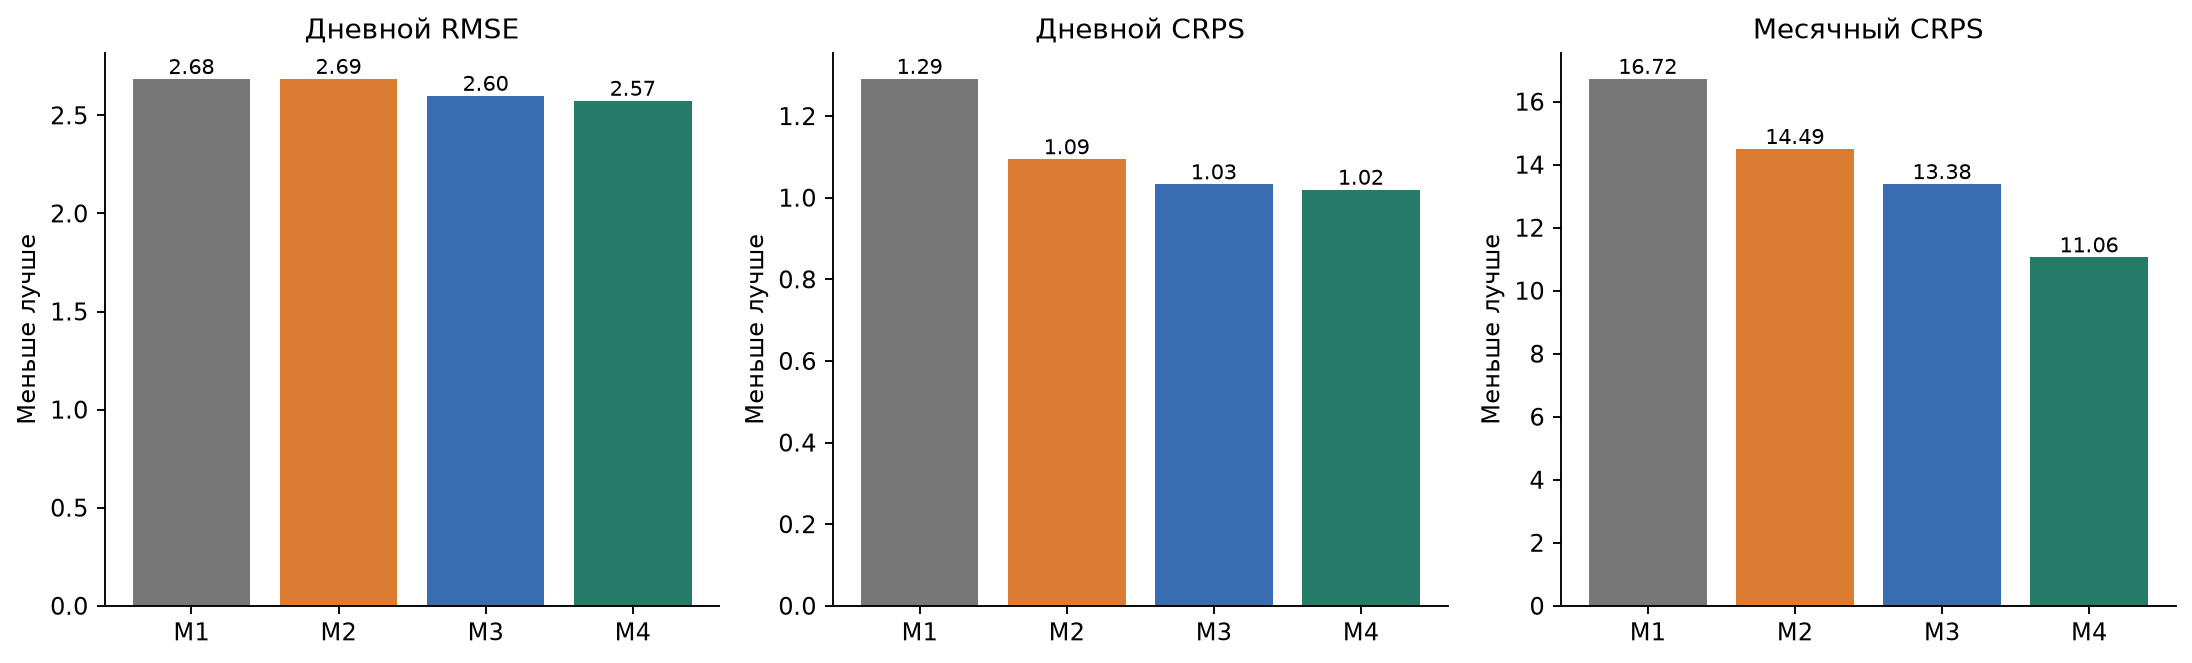

In [16]:
fig,axes=plt.subplots(1,3,figsize=(13,4))
for ax,metric,title in [(axes[0],'daily_rmse','Дневной RMSE'),(axes[1],'daily_crps','Дневной CRPS'),(axes[2],'monthly_crps','Месячный CRPS')]:
    ax.bar(evaluation.model,evaluation[metric],color=[COLORS[x] for x in evaluation.model])
    for i,v in enumerate(evaluation[metric]):ax.text(i,v,f'{v:.2f}',ha='center',va='bottom',fontsize=9)
    ax.set(title=title,ylabel='Меньше лучше')
show_plot(fig,'09_backtest_metrics.png')

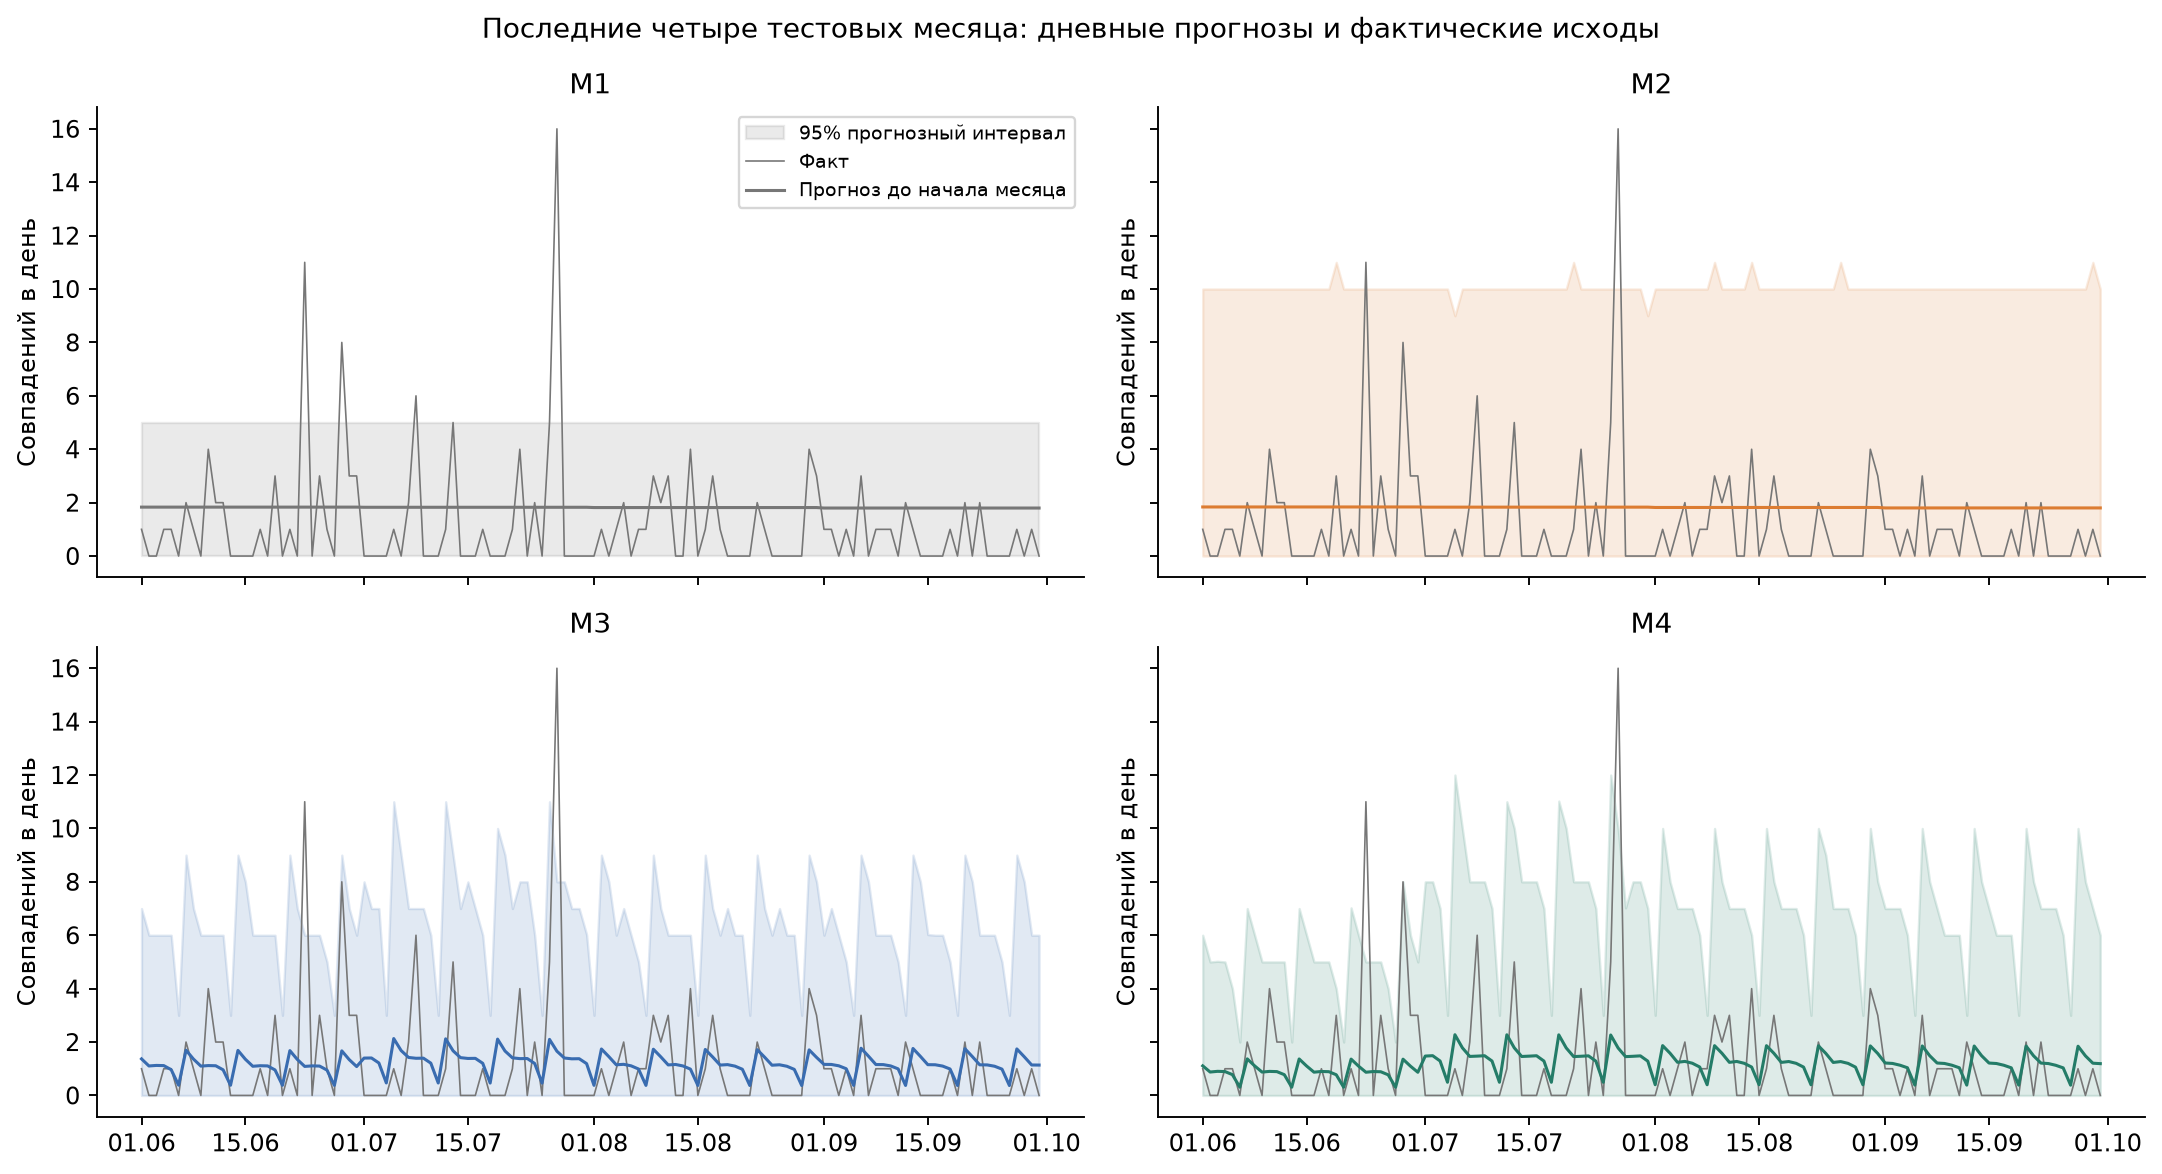

In [17]:
back=pd.read_csv(OUT/'backtest_daily.csv')
back['date']=pd.to_datetime(back.date)
window=(back.date>='2026-06-01')&(back.date<='2026-09-30')
fig,axes=plt.subplots(2,2,figsize=(13,7),sharex=True,sharey=True)
for ax,model in zip(axes.flat,NAMES):
    a=back[window&(back.model==model)]
    ax.fill_between(a.date,a.lo95,a.hi95,color=COLORS[model],alpha=.15,label='95% прогнозный интервал')
    ax.plot(a.date,a.actual,color='#777777',lw=.7,label='Факт')
    ax.plot(a.date,a['mean'],color=COLORS[model],lw=1.3,label='Прогноз до начала месяца')
    ax.set(title=model,ylabel='Совпадений в день')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
axes[0,0].legend(fontsize=8)
fig.suptitle('Последние четыре тестовых месяца: дневные прогнозы и фактические исходы')
show_plot(fig,'10_backtest_daily.png')

## 10. Проверка и сохранённые файлы

Проверяем количество дней, одинаковые прогнозные даты, целочисленные интервалы, согласованность месячных и дневных средних, воспроизведение предыдущих прогнозов и неизменность фильтра при включении истории для графика.

Основной дневной файл — `forecast_daily_all_models.csv`: 31 строка, средние четырёх моделей и интервалы M4. `forecast_daily_discrete.csv` содержит интервалы и вероятности для каждой модели, 124 строки. `filtered_state_history.csv` хранит данные графика работы фильтра. Все новые графики находятся в `figures/daily_models` и встроены в эту тетрадку.


In [18]:
assert len(dates)==31 and dates[0]==pd.Timestamp('2026-10-03') and dates[-1]==pd.Timestamp('2026-11-02')
assert len(wide)==31 and len(daily)==124 and daily.groupby('model').size().eq(31).all()
assert (daily[['lo80','hi80','lo95','hi95','median']].to_numpy()%1==0).all()
assert (daily[['lo80','hi80','lo95','hi95','median','mean']].to_numpy()>=0).all()
assert daily.probability_at_least_one.between(0,1).all()
previous=pd.read_csv(OUT/'forecast_daily.csv')
np.testing.assert_allclose(daily['mean'],previous['mean'],rtol=1e-12,atol=1e-12)
for _,row in monthly.iterrows():
    np.testing.assert_allclose(daily.loc[daily.model==row.model,'mean'].sum(),row['mean'])
_,states_without_trace,_=filter_state(d,fit3,q,8192,prediction_seed+14,trace=False)
np.testing.assert_array_equal(final_states,states_without_trace)
assert trace.observed.sum()==d.observed.sum()
validation={'status':'passed','days':31,'models':4,'daily_rows':124,'wide_rows':31,
            'forecast_reproduced':True,'trace_does_not_change_filter':True,
            'interval_quantile_method':'inverted_cdf','source_sha256':source_hash}
(OUT/'daily_notebook_validation.json').write_text(json.dumps(validation,indent=2),encoding='utf-8')
print('Все проверки прошли. Дневной прогноз сохранён для 31 дня и четырёх моделей.')

Все проверки прошли. Дневной прогноз сохранён для 31 дня и четырёх моделей.


## Методологические источники

Использованы материалы предыдущего расчёта: L1 Forecast Evaluation (форма прогноза, калибровка и оценка), L3 Bayesian Computation и `ha15491_6191_3.ipynb` (posterior predictive averaging, NB и MH), L4 Hierarchical Modeling и S4 (частичное объединение), L5 Sequential Forecasting (модель состояния, хронологическая оценка и фильтр частиц). Подробная привязка к страницам и все ограничения находятся в `README.md` рядом с тетрадкой.
